# Analysis notebook

[K-Fold](#kfold)
[Group fold](#group_fold)

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import (
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from scipy import stats
from sklearn.calibration import calibration_curve
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib
import os
from collections import defaultdict
from itertools import combinations, permutations
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests
import main2
import enrichment


%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
def timeit(func):
    """Function timer"""

    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        out = func(*args, **kwargs)
        print(f"> {func.__name__} :: {(time.perf_counter() - start):.3f} sec")
        return out

    return wrapper

In [33]:
def save_fig(
        fig: matplotlib.figure.Figure, 
        fig_name: str, 
        fig_dir: str, 
        fig_fmt: str,
        fig_size: tuple[float, float] = [6.4, 4], 
        save: bool = True, 
        dpi: int = 300,
        transparent_png = True,
    ):
    """This procedure stores the generated matplotlib figure to the specified 
    directory with the specified name and format.

    Parameters
    ----------
    fig : [type]
        Matplotlib figure instance
    fig_name : str
        File name where the figure is saved
    fig_dir : str
        Path to the directory where the figure is saved
    fig_fmt : str
        Format of the figure, the format should be supported by matplotlib 
        (additional logic only for pdf and png formats)
    fig_size : Tuple[float, float]
        Size of the figure in inches, by default [6.4, 4] 
    save : bool, optional
        If the figure should be saved, by default True. Set it to False if you 
        do not want to override already produced figures.
    dpi : int, optional
        Dots per inch - the density for rasterized format (png), by default 300
    transparent_png : bool, optional
        If the background should be transparent for png, by default True
    """
    if not save:
        return
    
    fig.set_size_inches(fig_size, forward=False)
    fig_fmt = fig_fmt.lower()
    fig_dir = os.path.join(fig_dir, fig_fmt)
    if not os.path.exists(fig_dir):
        os.makedirs(fig_dir)
    pth = os.path.join(
        fig_dir,
        '{}.{}'.format(fig_name, fig_fmt.lower())
    )
    print(pth)
    if fig_fmt == 'pdf':
        metadata={
            'Creator' : '',
            'Producer': '',
            'CreationDate': None
        }
        fig.savefig(pth, bbox_inches='tight', metadata=metadata)
    elif fig_fmt == 'png':
        alpha = 0 if transparent_png else 1
        axes = fig.get_axes()
        fig.patch.set_alpha(alpha)
        for ax in axes:
            ax.patch.set_alpha(alpha)
        fig.savefig(
            pth, 
            bbox_inches='tight',
            dpi=dpi,
        )
    else:
        try:
            fig.savefig(pth, bbox_inches='tight')
        except Exception as e:
            print("Cannot save figure: {}".format(e)) 

In [34]:
@timeit
def load_run(path: str, svm: bool = False) -> list[main2.Fold]:

    if svm:
        df = pd.read_parquet(f"../Experiments/svm/Log/{path}/output.parquet")
        # df = duckdb.read_parquet(f"../Experiments/svm/Log/{path}/output.parquet")
        # df = df.to_df()
        folds: list[Fold] = main2.create_dataset_svm(df)
    else:
        df = pd.read_parquet(f"../Log/{path}/output.parquet")
        folds: list[Fold] = main2.create_dataset(df)
    return folds

In [35]:
@timeit
def load_run(path: str, mtype: str = 'dl') -> list[main2.Fold]:

    if mtype=='svm':
        df = pd.read_parquet(f"../Experiments/svm/Log/{path}/output.parquet")
        # df = duckdb.read_parquet(f"../Experiments/svm/Log/{path}/output.parquet")
        # df = df.to_df()
        folds: list[Fold] = main2.create_dataset_svm(df)
    elif mtype=='gbm':
        # Heyne Modle
        df = pd.read_csv(f"../funNCion_ours/{path}.csv")
        folds: list[Fold] = main2.create_dataset_svm(df)
    else:
        df = pd.read_parquet(f"../Log/{path}/output.parquet")
        folds: list[Fold] = main2.create_dataset(df)
    return folds

In [36]:
# def load_run_dict(runs: dict[str, str]):
#     for k, v in runs.items():
#         if '(svm)' in k:
#             runs[k] = load_run(v, svm=True)
#         else:
#             runs[k] = load_run(v)

#     for k, v in runs.items():
#         for e in range(len(v)):
#             v[e].get_best_epoch()
#     return runs

# Support new model type
def load_run_dict(runs: dict[str, str]):
    for k, v in runs.items():
        if '(svm)' in k:
            runs[k] = load_run(v, mtype='svm')
        elif '(gbm)' in k:
            runs[k] = load_run(v, mtype='gbm')
        else:
            runs[k] = load_run(v)

    for k, v in runs.items():
        for e in range(len(v)):
            v[e].get_best_epoch()
    return runs

In [37]:
runs = {
    '3B': 'RepeatedKFold/esm',
}
runs = load_run_dict(runs)

> load_run :: 0.767 sec


In [38]:
f = runs['3B'][0]

print(f.fold)
print('preds:', f.preds.shape)
print('labels:', f.labels.shape)

0
preds: (20, 318, 2)
labels: (20, 318, 2)


# Figure 3

<a id='kfold'></a>

    A simple 2 panel ROC - PR curve plot comparing our model, boselmann, and Heyne. 

In [256]:
runs = {
    'ours': 'RepeatedKFold/esm_bf_go_fl',
    # 'ours': 'test',
    # 'ours': 'RepeatedKFold_norm/esm_bf_go_fl',
    # 'ours': 'Ablation2/esm_bf_go',
    # 'ours': 'attn_with_mask_bf_go',
    # 'ours': 'RepeatedKFold/esm_attn_with_mask_bf_go_mwt_fl',
    # 'ours': 'RepeatedKFold/esm_bf_go_fl_mwt_attn',
    # 'esm bf go hpo fl mwt': 'RepeatedKFold/esm_bf_go_hpo_fl_mwt',
    # 'ours_hpo': 'RepeatedKFold/esm_bf_go_hpo_fl_mwt',
    'ours hpo': 'RepeatedKFold/esm_bf_go_hpo_fl',
    # '(svm)mtl': 'mtl',
    '(svm)mtl': 'RepeatedKFold/mtl',
    # '(svm)mkl': 'mkl',
    '(svm)mkl': 'RepeatedKFold/mkl',
    '(svm)mtl-b': 'bosselman_dataset_mtl',
    '(svm)mkl-b': 'bosselman_dataset_mkl',
}

runs = {
    'ours': 'fixed_heyne_1',
    '(svm)mtl': 'fixed_heyne_svm',
    'esmc600': 'esmc600m',
    'esmc600_bf_go': 'esmc600m_bf_go',
    # '650m': 'fixed_heyne_650m',
    # '804': 'heyne_804',
    # '(gbm)heyne': 'heyne_output',
    # '(gbm)heyne2': 'heyne_impute_output',
    # '(gbm)heyneNavCav': 'heyne_impute_navcav_output',
    '(gbm)heyne': 'heyne_impute_scaler_output',
    # '(gbm)heyne NavCav': 'heyne_impute_navcav_scaler_output',
}
runs = {   
    # '1996': '1996_1180',
    'ours': 'fixed_heyne_1',
    '(svm)mtl': 'fixed_heyne_svm',
    '(svm)mtl_no_am': 'no_am_esm_llr',
    # 'hpo': 'fixed_heyne_hpo_only',
    # '3b_bf': 'Fixed_Heyne/3b_bf',
    # '3b_go': 'Fixed_Heyne/3b_go',
    # 'go_bf': 'Fixed_Heyne/go_bf',
    # '3b': 'Fixed_Heyne/esm3b',
    # 'go': 'Fixed_Heyne/go',
    # 'bf': 'Fixed_Heyne/bf',
    # 'hpo': 'Fixed_Heyne/hpo',
}

# runs = {
#     '3b': 'Fixed_Heyne/esm3b',
#     '650': 'Fixed_Heyne/esm_650m',
#     '150': 'Fixed_Heyne/esm_150m',
#     '35': 'Fixed_Heyne/esm_35m',
#     '8': 'Fixed_Heyne/esm_8m',
# }

# runs = {
#     '3b': 'Fixed_Heyne/esm3b',
#     'go': 'Fixed_Heyne/go',
#     'bf': 'Fixed_Heyne/bf',
#     'hpo': 'Fixed_Heyne/hpo',
# }
# runs = {   
#     'MissION': 'fixed_heyne_1',
#     '3b': 'Fixed_Heyne/esm3b',
#     'go': 'Fixed_Heyne/go',
#     'bf': 'Fixed_Heyne/bf',
#     'hpo': 'Fixed_Heyne/hpo',
# }

runs = {
    'ex. pLM': 'Fixed_Heyne/3b_go',
    'ex. GO': 'Fixed_Heyne/3b_bf',
    'ex. SSR': 'Fixed_Heyne/go_bf',
}

# runs = {
#     '1': 'Fixed_Heyne/cut_size/1',
#     '5': 'Fixed_Heyne/cut_size/5',
#     '10': 'Fixed_Heyne/cut_size/10',
#     '50': 'Fixed_Heyne/cut_size/50',
#     '100': 'Fixed_Heyne/cut_size/100',
#     '200': 'Fixed_Heyne/cut_size/200',
#     '300': 'Fixed_Heyne/cut_size/300',
#     '400': 'Fixed_Heyne/cut_size/400',
#     # '500': 'Fixed_Heyne/cut_size/500',
# }
runs = load_run_dict(runs)

> load_run :: 0.599 sec
> load_run :: 0.555 sec
> load_run :: 0.536 sec


In [257]:
def compute_roc(folds: list[main2.Fold]):
    """ Computes data for plotting ROC curve """
    ps = []
    ls = []
    tprs = []
    aucs = []
    thresholds = []
    thresholds_best = []
    for ii, fold in enumerate(folds):
        epoch = fold.best_epoch
        p = fold.preds[epoch]
        l = fold.labels[epoch]

        if p.ndim > 1:
            p = p[:, 1]
            l = np.argmax(l, 1)

        ps.append(p)
        ls.append(l)

        mean_fpr = np.linspace(0, 1, 100)
        fpr, tpr, threshold = roc_curve(l, p)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        thresholds.append(threshold)
        thresholds_best.append(np.argmax(tpr - fpr))
        tprs.append(interp_tpr)
        aucs.append(auc(fpr, tpr))

    mean_tpr = np.mean(tprs, 0)
    mean_tpr[-1] = 1.0
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    return {
        'fpr': mean_fpr, 
        'tpr': mean_tpr, 
        'auc': mean_auc, 
        'std': std_auc
    }

def compute_pr(folds: list[main2.Fold]):
    """ Computes Precision-Recall """
    ls = []
    ps = []
    for fold in folds:
        epoch = fold.get_best_epoch()
        p = fold.preds[epoch]
        l = fold.labels[epoch]

        if p.ndim > 1:
            p = p[:, 1]
            l = np.argmax(l, 1)

        ls.append(l)
        ps.append(p)

    ps = np.concatenate(ps)
    ls = np.concatenate(ls)
    
    precision, recall, thresholds = precision_recall_curve(ls, ps)
    # score = average_precision_score(ls, ps)
    score = auc(recall, precision)

    # To make the plot nicer, I interpolate incase there are any precision drops to 0
    # precision = interpolate_zeros(precision)

    return {
        'precision': precision,
        'recall': recall,
        'threshold': thresholds,
        'score': score
    }

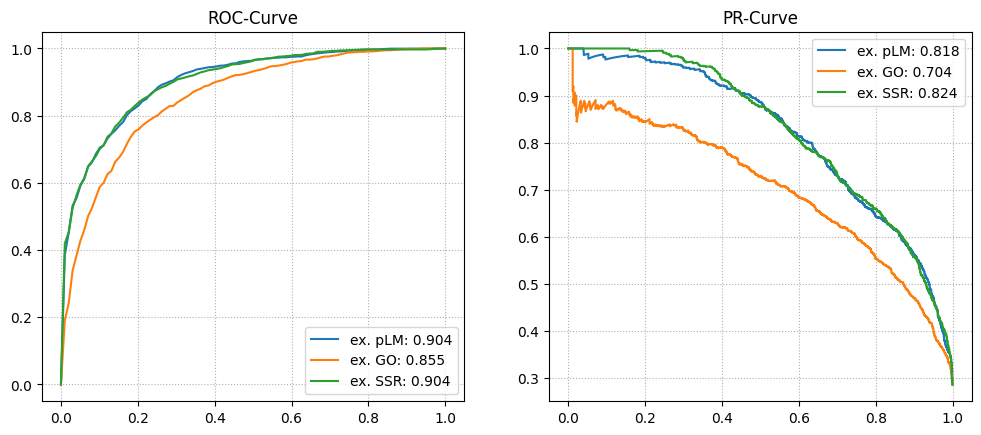

In [258]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
for k, v in runs.items():
    
    roc_d = compute_roc(v)
    ax[0].plot(roc_d['fpr'], roc_d['tpr'], linewidth=1.5, label=f"{k}: {roc_d['auc']:.3f}")

    roc_d = compute_pr(v)
    ax[1].plot(roc_d['recall'], roc_d['precision'],  linewidth=1.5, label=f"{k}: {roc_d['score']:.3f}")

ax[0].legend()
ax[1].legend()
ax[0].grid(linestyle=":")
ax[1].grid(linestyle=":")

ax[0].set_title('ROC-Curve')
ax[1].set_title("PR-Curve")
plt.show()

> load_run :: 0.409 sec
> load_run :: 0.019 sec
ours std: 0.02807948160661432
scion std: 0.028060962109344573
./review_figures/png/MissION_HPO_SCION_MKL.png


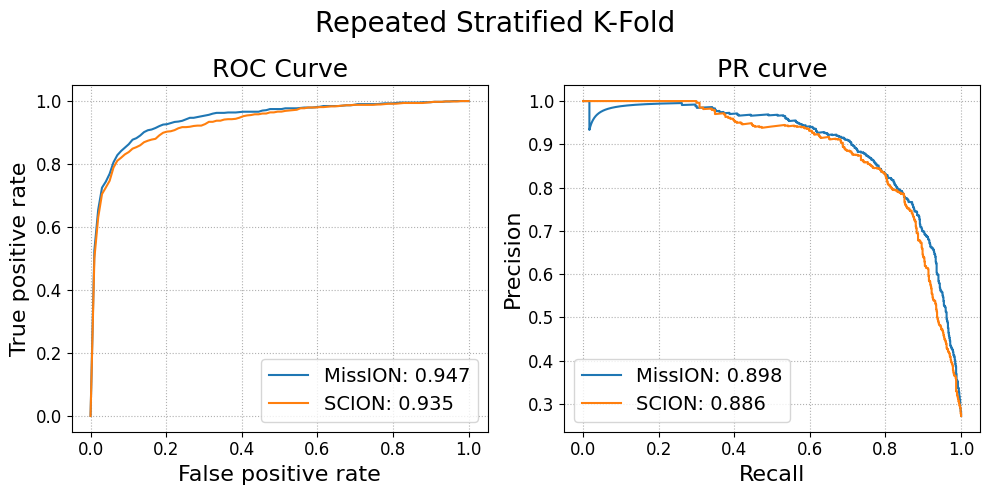

'\nPreviously\n0.925  0.864\n0.897  0.813\n\nAfter removing Heyne variants\n0.918  0.838\n0.884  0.784\n'

In [287]:
runs = {
    # 'ours': 'fixed_heyne_1',
    # '(svm)mtl': 'fixed_heyne_svm',
    # '(gbm)funNCion': 'heyne_impute_scaler_output_rskf_2', # _2 => hyperparameter tuned
    # # '(gbm)heyne NavCav': 'heyne_impute_navcav_scaler_output',\

    # HPO
    'ours': 'fixed_heyne_hpo_only',
    '(svm)mtl': 'fixed_heyne_mkl',

}
runs = load_run_dict(runs)

fig_size = (10, 5) #4.8)

fig, ax = plt.subplots(1, 2, figsize=fig_size, tight_layout=True)

fontsize_title = 18
fontsize_suptitle = 20
fontsize_label = 16

roc_d = compute_roc(runs['ours'])
print('ours std:', roc_d['std'])
ax[0].plot(roc_d['fpr'], roc_d['tpr'], linewidth=1.5, label=f"MissION: {roc_d['auc']:.3f}")

roc_d = compute_roc(runs['(svm)mtl'])
print('scion std:', roc_d['std'])
ax[0].plot(roc_d['fpr'], roc_d['tpr'], linewidth=1.5, label=f"SCION: {roc_d['auc']:.3f}")

# roc_d = compute_roc(runs['(gbm)funNCion'])
# print('funNCion std:', roc_d['std'])
# ax[0].plot(roc_d['fpr'], roc_d['tpr'], linewidth=1.5, label=f"funNCion: {roc_d['auc']:.3f}")

# roc_d = compute_roc(runs['(svm)SCION'])
# ax[0].plot(roc_d['fpr'], roc_d['tpr'], linewidth=1.5, label=f"SCION: {roc_d['auc']:.3f}")


ax[0].grid(linestyle=':')
ax[0].legend(fontsize=14)
ax[0].set_title("ROC Curve", fontsize=fontsize_title)
ax[0].set_xlabel("False positive rate", fontsize=fontsize_label)
ax[0].set_ylabel("True positive rate", fontsize=fontsize_label)
# ----------------- ax-1 --------------------

roc_d = compute_pr(runs['ours'])
ax[1].plot(roc_d['recall'], roc_d['precision'],  linewidth=1.5, label=f"MissION: {roc_d['score']:.3f}")

roc_d = compute_pr(runs['(svm)mtl'])
ax[1].plot(roc_d['recall'], roc_d['precision'],  linewidth=1.5, label=f"SCION: {roc_d['score']:.3f}")

# roc_d = compute_pr(runs['(gbm)funNCion'])
# ax[1].plot(roc_d['recall'], roc_d['precision'],  linewidth=1.5, label=f"funNCion: {roc_d['score']:.3f}")

# roc_d = compute_pr(runs['(svm)SCION'])
# ax[1].plot(roc_d['recall'], roc_d['precision'],  linewidth=1.5, label=f"SCION: {roc_d['score']:.3f}")


ax[1].grid(linestyle=':')
ax[1].legend(fontsize=14, loc=3)
ax[1].set_title("PR curve", fontsize=fontsize_title)
ax[1].set_xlabel("Recall", fontsize=fontsize_label)
ax[1].set_ylabel("Precision", fontsize=fontsize_label)

for i in [0, 1]:
    ax[i].tick_params(axis='x', labelsize=12)
    ax[i].tick_params(axis='y', labelsize=12)

plt.suptitle("Repeated Stratified K-Fold", fontsize=fontsize_suptitle)

save_fig(fig, 'MissION_HPO_SCION_MKL', fig_dir='./review_figures/', fig_fmt='png', fig_size=fig_size, transparent_png=False, dpi=300)
plt.show()

"""
Previously
0.925  0.864
0.897  0.813

After removing Heyne variants
0.918  0.838
0.884  0.784
"""

# Figure 4

    Confidence and threshold plots
    3 panels
    

In [233]:
runs = {
    'ours': 'fixed_heyne_1', # RepeatedKFold(3, 10)
    '(svm)mtl': 'fixed_heyne_svm' # RpeatedKFold(3, 10)
}
runs = load_run_dict(runs)

> load_run :: 1.073 sec
> load_run :: 0.034 sec


## Figure 4.1 Real vs confidence + Calibration curve

In [234]:
def real_vs_confidence(folds: list[main2.Fold]):
    gof_ls =[]
    lof_ls = []
    for i, fold in enumerate(folds):
        p = fold.preds[fold.best_epoch]
        l = fold.labels[fold.best_epoch]
        lofs = np.where(l[:, 0] == 1)[0]
        gofs = np.where(l[:, 1] == 1)[0]

        lofs = p[lofs, 0]
        gofs = p[gofs, 1]
        lof_ls.extend(lofs)
        gof_ls.extend(gofs)
    return gof_ls, lof_ls

gof_ls, lof_ls = real_vs_confidence(runs['ours'])

# # fig, ax1 = plt.subplots(1, 1)
# ax1 = ax[0]

# noise = gof_ls
# density1 = stats.gaussian_kde(noise)
# n, x1, _ = ax1.hist(noise, bins=np.linspace(0, 1, 101), 
#                    histtype='bar', alpha=0.5, density=True, stacked=True, label='GOF')  


# noise = 1 - np.array(lof_ls)
# density2 = stats.gaussian_kde(noise)
# n, x2, _ = ax1.hist(noise, bins=np.linspace(0, 1, 101), 
#                    histtype='bar', alpha=0.5, density=True, stacked=True, label="LOF", color="tab:red")

# # ax1.set_title("Prediction confidence coloured by ground truth", fontsize=fontsize_title)
# ax1.set_ylabel('Density', fontsize=14)
# ax1.set_xlabel('probability of GOF', fontsize=14)
# ax1.legend(fontsize=12, loc=9)

def make_panel_1(gof_ls, lof_ls, ax):
    noise = gof_ls
    density1 = stats.gaussian_kde(noise)
    n, x1, _ = ax.hist(noise, bins=np.linspace(0, 1, 101), 
                       histtype='bar', alpha=0.5, density=True, stacked=True, label='GOF')  
    
    
    noise = 1 - np.array(lof_ls)
    density2 = stats.gaussian_kde(noise)
    n, x2, _ = ax.hist(noise, bins=np.linspace(0, 1, 101), 
                       histtype='bar', alpha=0.5, density=True, stacked=True, label="LOF", color="tab:red")
    
    # ax1.set_title("Prediction confidence coloured by ground truth", fontsize=fontsize_title)
    ax.set_ylabel('Density', fontsize=14)
    ax.set_xlabel('probability of GOF', fontsize=14)
    ax.legend(fontsize=12, loc=9)
    return ax

In [235]:
""" Calibration Curve """
def compute_calibration(folds: list[main2.Fold]):
    prob_true_ls = []
    prob_pred_ls = []
    for i, fold in enumerate(folds):
        p = fold.preds[fold.best_epoch]
        l = fold.labels[fold.best_epoch]

        prob_true, prob_pred = calibration_curve(np.argmax(l, 1), p[:, 1], pos_label=1, n_bins=10)
        prob_true_ls.append(prob_true)
        prob_pred_ls.append(prob_pred)

    return prob_true_ls, prob_pred_ls

a, b = compute_calibration(runs['ours'])
def make_panel_cb(a, b, ax):

    ax1_1 = ax.twinx()
    ax1_1.plot(np.linspace(0, 1, 10), np.linspace(0, 1, 10), linestyle=':', color='k', label='Perfect')
    
    ax1_1.set_yticks([])

    a = np.array(a)
    b = np.array(b)
    ax1_1.errorbar(np.mean(b, 0), np.mean(a, 0), yerr=np.std(a, 0)/np.sqrt(a.shape[0]), capsize=2)
    ax1_1.plot(np.mean(b, 0), np.mean(a, 0))
    return ax
        

## Figure 4.2 Threshold plot

    Plots precision and recall against score for each class

In [241]:
# ------------------------------------------------------
# 1. Collect best-epoch predictions across folds
# ------------------------------------------------------
# preds = []
# labels = []

# for fold in runs["ours"]:
#     be = fold.get_best_epoch()
#     p = fold.preds[be, :, 1]     # GOF probability
#     l = fold.labels[be, :, 1]    # GOF label (0=LOF,1=GOF)
#     preds.append(p)
#     labels.append(l)

# y_scores = np.concatenate(preds)
# y_true   = np.concatenate(labels)

# # ------------------------------------------------------
# # 2. Define threshold sweeps
# # ------------------------------------------------------
# t_lof  = np.linspace(0.001, 0.5,   100)
# t_gof  = np.linspace(0.5,   0.999, 100)

def sweep_metrics(thresholds, positive_label, predicate):
    """Compute precision, recall, expected precision for a slice of thresholds."""
    P, R, EP = [], [], []

    true_pos = (y_true == positive_label).astype(int)

    for t in thresholds:
        pred = predicate(y_scores, t).astype(int)

        P.append(precision_score(true_pos, pred, pos_label=1, zero_division=0))
        R.append(recall_score(true_pos, pred, pos_label=1, zero_division=0))

        # expected precision = mean(score) or mean(1 - score)
        mask = pred == 1
        if mask.any():
            if positive_label == 0:
                EP.append(np.mean(1 - y_scores[mask]))
            else:
                EP.append(np.mean(y_scores[mask]))
        else:
            EP.append(0)

    return np.array(P), np.array(R), np.array(EP)

def sweep_metrics(y_true, y_scores, thresholds, positive_label, predicate):
    """
    Returns:
        precision(t)
        recall(t)
        expected_precision(t)
        expected_recall(t)
    """
    P, R, EP, ER = [], [], [], []

    true_pos = (y_true == positive_label).astype(int)

    for t in thresholds:
        pred = predicate(y_scores, t).astype(int)

        # Precision & recall
        P.append(precision_score(true_pos, pred, pos_label=1, zero_division=0))
        R.append(recall_score(true_pos, pred, pos_label=1, zero_division=0))

        # ---------- Expected Precision ----------
        mask_pred_pos = pred == 1
        if mask_pred_pos.any():
            if positive_label == 0:
                EP.append(np.mean(1 - y_scores[mask_pred_pos]))
            else:
                EP.append(np.mean(y_scores[mask_pred_pos]))
        else:
            EP.append(0)

        # ---------- Expected Recall ----------
        # average confidence among TRUE positives that were retrieved
        mask_true_pos = (true_pos == 1) & (mask_pred_pos)
        if mask_true_pos.any():
            if positive_label == 0:
                ER.append(np.mean(1 - y_scores[mask_true_pos]))
            else:
                ER.append(np.mean(y_scores[mask_true_pos]))
        else:
            ER.append(0)

    return map(np.array, (P, R, EP, ER))


def precision_threshold_plot(folds: list[main2.Fold], ax = None):
    preds = []
    labels = []
    
    for fold in runs["ours"]:
        be = fold.get_best_epoch()
        p = fold.preds[be, :, 1]     # GOF probability
        l = fold.labels[be, :, 1]    # GOF label (0=LOF,1=GOF)
        preds.append(p)
        labels.append(l)
    
    y_scores = np.concatenate(preds)
    y_true   = np.concatenate(labels)
    
    # ------------------------------------------------------
    # 2. Define threshold sweeps
    # ------------------------------------------------------
    t_lof  = np.linspace(0.001, 0.5,   100)
    t_gof  = np.linspace(0.5,   0.999, 100)

    
    # LOF metrics
    prec_lof, rec_lof, exp_lof, exp_rec_lof = sweep_metrics(
        y_true, y_scores,
        t_lof, positive_label=0,
        predicate=lambda s, t: s <= t
    )
    
    # GOF metrics
    prec_gof, rec_gof, exp_gof, exp_rec_gof = sweep_metrics(
        y_true, y_scores,
        t_gof, positive_label=1,
        predicate=lambda s, t: s >= t
    )
    
    # ------------------------------------------------------
    # 3. Compute 90% precision thresholds
    # ------------------------------------------------------
    target = 0.90
    
    # LOF: highest threshold >= target precision
    idx = np.where(prec_lof >= target)[0]
    thresh_lof_90 = t_lof[idx[-1]] if len(idx) else t_lof[-1]
    prec_lof_90   = prec_lof[idx[-1]] if len(idx) else prec_lof[-1]
    
    # GOF: lowest threshold >= target precision
    idx = np.where(prec_gof >= target)[0]
    thresh_gof_90 = t_gof[idx[0]] if len(idx) else t_gof[0]
    prec_gof_90   = prec_gof[idx[0]] if len(idx) else prec_gof[0]
    
    # ------------------------------------------------------
    # 4. Plotting
    # ------------------------------------------------------
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # LOF curves (red)
    ax.plot(t_lof, prec_lof, color='tab:red', linestyle='-',  label="precision (LOF)")
    ax.plot(t_lof, rec_lof,  color='tab:red', linestyle='-.', label="recall (LOF)")
    ax.plot(t_lof, exp_lof,  color='tab:red', linestyle=':',  label="expected precision (LOF)")
    # ax.plot(t_lof, exp_rec_lof, color='tab:red', linestyle='--', label="expected recall (LOF)")
    
    # GOF curves (blue)
    ax.plot(t_gof, prec_gof, color='tab:blue', linestyle='-',  label="precision (GOF)")
    ax.plot(t_gof, rec_gof,  color='tab:blue', linestyle='-.', label="recall (GOF)")
    ax.plot(t_gof, exp_gof,  color='tab:blue', linestyle=':',  label="expected precision (GOF)")
    # ax.plot(t_gof, exp_rec_gof, color='tab:blue', linestyle='--', label="expected recall (GOF)")
    
    # 90% precision markers
    ax.axhline(target, color='black', linestyle='--', linewidth=0.8)
    
    ax.plot(thresh_lof_90, prec_lof_90, 'o', color='tab:red')
    ax.vlines(thresh_lof_90, 0, prec_lof_90, color='black', linestyle='--')
    
    ax.plot(thresh_gof_90, prec_gof_90, 'o', color='tab:blue')
    ax.vlines(thresh_gof_90, 0, prec_gof_90, color='black', linestyle='--')
    
    # Labels and cosmetics
    ax.set_xlabel("Score threshold", fontsize=14)
    ax.set_ylabel("Precision or Recall", fontsize=14)
    ax.set_ylim(-0.025, 1.05)
    ax.set_xlim(-0.0125, 1.0125)
    ax.grid(linestyle='--', alpha=0.2)
    ax.axvline(0.5, color='k')
    
    # Category labels
    ax.text(0.02, 1.01, "Likely\nLOF", color='tab:red', transform=ax.transAxes,
            ha='left', va='bottom', fontsize=11, fontweight='bold', clip_on=False)
    ax.text(0.98, 1.01, "Likely\nGOF", color='tab:blue', transform=ax.transAxes,
            ha='right', va='bottom', fontsize=11, fontweight='bold', clip_on=False)
    ax.text(0.5, 1.01, "Ambiguous", color='gray', transform=ax.transAxes,
            ha='center', va='bottom', fontsize=11, fontweight='bold', clip_on=False)
    
    # --- threshold text labels ---
    ax.text(thresh_lof_90,  prec_lof_90  + 0.05,
            f"{thresh_lof_90:.2f}", ha='center', va='bottom',
            color='tab:red', fontsize=12)
    
    ax.text(thresh_gof_90,  prec_gof_90  + 0.05,
            f"{thresh_gof_90:.2f}", ha='center', va='bottom',
            color='tab:blue', fontsize=12)

    # ax.legend()
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', lw=1.5, linestyle='-', label='precision'),
        Line2D([0], [0], color='black', lw=1.5, linestyle='-.', label='recall'),
        Line2D([0], [0], color='black', lw=1.5, linestyle=':', label='expected precision')
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True, edgecolor='lightgray')

    # plt.tight_layout()
    # plt.show()
    return ax


In [242]:
""" 
Error rate bins vs prediction value
Bar plot
"""

# --------------------------
# Data extraction utilities
# --------------------------

def extract_gof(folds):
    """Return (probabilities, predicted_labels, true_labels)."""
    probs, labels = [], []

    for fold in folds:
        p = fold.preds[fold.best_epoch]
        l = fold.labels[fold.best_epoch]
        probs.append(p[:, 1])     # GOF probability
        labels.append(l[:, 1])    # GOF label

    probs = np.concatenate(probs)
    labels = np.concatenate(labels)
    preds = (probs > 0.5).astype(int)

    return probs, preds, labels


# --------------------------
# Histogram smoothing utility
# --------------------------

def sliding_window_counts(values, window=0.05, step=0.01):
    """Return count of samples inside sliding windows."""
    values = np.sort(values)
    starts = np.arange(0.5, 1.0, step)
    counts = [np.sum((values >= s) & (values < s + window)) for s in starts]
    return np.array(counts), starts


# --------------------------
# Confidence extraction
# --------------------------

def prediction_confidences(probs, preds, labels):
    """Return LOF/GOF confidence arrays and the subsets where model was wrong."""
    gof_conf = probs[preds == 1]
    lof_conf = 1 - probs[preds == 0]

    wrong_gof_conf = probs[(preds == 1) & (labels == 0)]
    wrong_lof_conf = 1 - probs[(preds == 0) & (labels == 1)]

    return gof_conf, lof_conf, wrong_gof_conf, wrong_lof_conf


# --------------------------
# Plotting
# --------------------------

def plot_confidence_error_rate(folds, ax, bins=np.linspace(0.5, 1, 11)):
    probs, preds, labels = extract_gof(folds)
    gof, lof, wrong_gof, wrong_lof = prediction_confidences(probs, preds, labels)

    # histograms
    gof_hist, _ = np.histogram(gof, bins=bins)
    lof_hist, _ = np.histogram(lof, bins=bins)

    wrong_gof_hist, _ = np.histogram(wrong_gof, bins=bins)
    wrong_lof_hist, _ = np.histogram(wrong_lof, bins=bins)

    gof_err = 100 * wrong_gof_hist / np.maximum(gof_hist, 1)
    lof_err = 100 * wrong_lof_hist / np.maximum(lof_hist, 1)

    # sliding-window curves
    gof_win, xs = sliding_window_counts(gof)
    wr_gof_win, _ = sliding_window_counts(wrong_gof)
    lof_win, _ = sliding_window_counts(lof)
    wr_lof_win, _ = sliding_window_counts(wrong_lof)

    gof_curve = 100 * wr_gof_win / np.maximum(gof_win, 1)
    lof_curve = 100 * wr_lof_win / np.maximum(lof_win, 1)

    # bar midpoints
    bin_centers = (bins[:-1] + bins[1:]) / 2
    width = (bins[1] - bins[0]) * 0.4

    # --------------------------
    # Plot
    # --------------------------
    # fig, ax = plt.subplots(figsize=(10, 4))

    ax.bar(bin_centers - width/2, gof_err, width=width, label="GOF", alpha=1)
    ax.bar(bin_centers + width/2, lof_err, width=width, label="LOF", alpha=1, color='tab:red')

    # ax.plot(xs + 0.025, gof_curve, lw=2)
    # ax.plot(xs + 0.025, lof_curve, lw=2, color='tab:red')

    ax.set_xlabel("Predicted score")
    ax.set_ylabel("Error rate (%)")
    ax.set_xticks(bins)
    ax.set_xticklabels([f"{b:.2f}" for b in bins], rotation=90)
    ax.grid(ls="dashed", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    # return fig, ax
    return ax

In [243]:
def plot_loess_error_rate(probs, preds, labels, ax, frac=0.15, flip:bool=False):
    """
    Plot LOESS-smoothed error rate vs predicted confidence.

    probs   : predicted probability of GOF (float values in [0,1])
    preds   : predicted labels (0/1)
    labels  : true labels (0/1)
    frac    : smoothing parameter (0.1–0.3 typical)
    """
    # Binary error signal
    errors = (preds != labels).astype(float)

    # Sort by confidence (LOESS does best with sorted x)
    order = np.argsort(probs)
    x = probs[order]
    y = errors[order]

    # Run LOWESS
    smoothed = lowess(y, x, frac=frac, it=0, return_sorted=True)
    xs = smoothed[:, 0]
    ys = smoothed[:, 1] * 100  # percent

    # Cut plot in half (LOF/GOF)
    xs_lidx = np.where(xs < 0.5)[0]
    xs_gidx = np.where(xs >= 0.5)[0]
    xs_l = 1 - xs[xs_lidx]
    ys_l = ys[xs_lidx]

    xs_g = xs[xs_gidx]
    ys_g = ys[xs_gidx]

    # ----- Plot -----
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4))
    if flip:
        ax.plot(xs_g, ys_g, linewidth=2, color='tab:blue')
        ax.plot(xs_l, ys_l, linewidth=2, color='tab:red')
    else:
        ax.plot(xs, ys, linewidth=2)
    ax.set_xlabel("Predicted Confidence")
    ax.set_ylabel("Error Rate (%)")
    ax.set_ylim(0-ys.max() * 0.05, ys.max() * 1.15)
    ax.grid(alpha=0.3, linestyle='dashed')
    # ax.set_title("LOESS-Smoothed Error Rate")
    # ax.tight_layout()
    ax.legend()

    return xs, ys


# folds = runs['ours']

# preds = []
# probs =[]
# labels = []
# for fold in folds:
#     epoch = fold.best_epoch
#     pb = fold.preds[epoch]
#     l = fold.labels[epoch]
#     pred = np.argmax(pb, 1)
#     pb = pb[:, 1]
#     l = np.argmax(l, 1)
#     preds.extend(pred)
#     probs.extend(pb)
#     labels.extend(l)

# plot_loess_error_rate(np.array(probs), np.array(preds), np.array(labels), None, frac=0.1, flip=False)

./review_figures/png/Fig_4.png


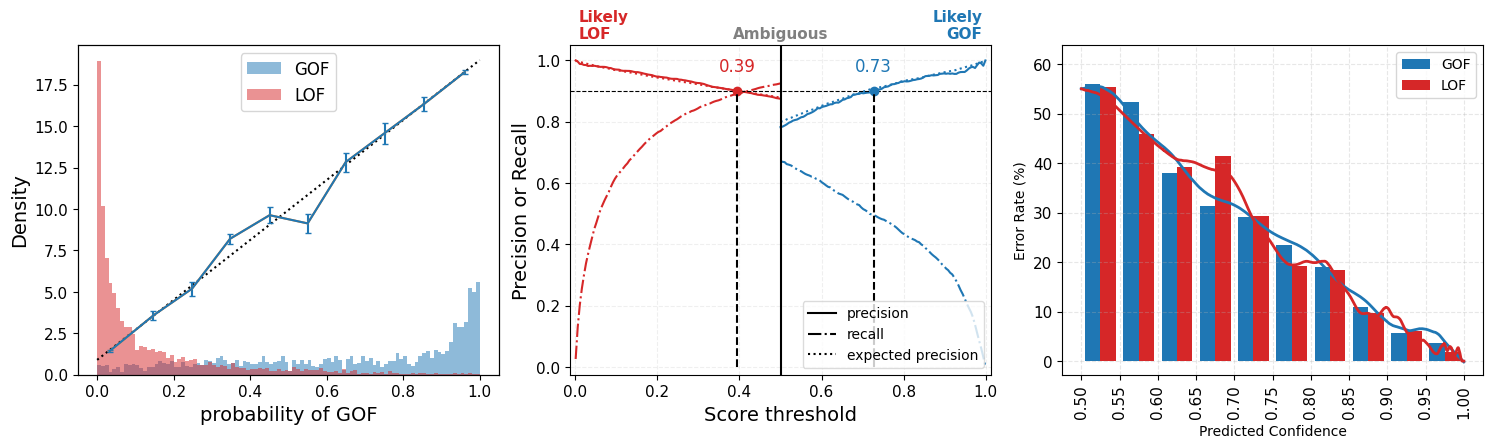

In [250]:
fig_size=(15, 4.8)
fig, ax = plt.subplots(1, 3, figsize=fig_size, tight_layout=True)

make_panel_1(gof_ls, lof_ls, ax[0])
make_panel_cb(a, b, ax[0])

plot_confidence_error_rate(runs['ours'], ax[2])

# ax0 = ax[0].twinx()
# ax0.set_ylabel('GOF fraction', rotation=-90, labelpad=0)

precision_threshold_plot(runs['ours'], ax[1])

# ===== LOESS PLOT =====
folds = runs['ours']
preds = []
probs =[]
labels = []
for fold in folds:
    epoch = fold.best_epoch
    pb = fold.preds[epoch]
    l = fold.labels[epoch]
    pred = np.argmax(pb, 1)
    pb = pb[:, 1]
    l = np.argmax(l, 1)
    preds.extend(pred)
    probs.extend(pb)
    labels.extend(l)

plot_loess_error_rate(np.array(probs), np.array(preds), np.array(labels), ax[2], frac=0.075, flip=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])

for i in [0, 1, 2]:
    ax[i].tick_params(axis='x', labelsize=11)
    ax[i].tick_params(axis='y', labelsize=11)

save_fig(fig, 'Fig_4', fig_dir='./review_figures/', fig_fmt='png', fig_size=fig_size, transparent_png=False, dpi=300)

plt.show()

# Figure 5

<a id='group_fold'></a>

    Group fold plot

In [493]:
runs = {
    # 'MissION': 'group_fold_fixed_heyne',
    # 'MissION': 'fixed_heyne_group_fold', # Pre-split Data/data_splits/fixed_heyne_group_fold
    'MissION': 'fixed_heyne_group_fold_shuffled', # KFold_cv (Best)
    # # 'MissION (HPO)': 'fixed_heyne_group_fold_hpo',
    '(svm)SCION': 'group_fold_fixed_heyne_svm_decision_function',
    '(gbm)funNCion': 'heyne_impute_scaler_output_gkf',

    # HPO
    # 'MissION': 'fixed_|heyne_group_fold_hpo',
    # # '(svm)SCION': 'group_fold_fixed_heyne_svm_decision_function',
    # '(svm)SCION': 'fixed_heyne_group_fold_hpo',
}
runs = load_run_dict(runs)

> load_run :: 0.385 sec
> load_run :: 0.032 sec
> load_run :: 0.032 sec


In [494]:
import copy 
def generate_fake_folds(folds: list[main2.Fold], seed: int = 42, shuffle=False) -> list[main2.Fold]:
    """
    Creates a new list of Fold objects with randomized predictions.
    Maintains the structure of the original folds.
    """
    np.random.seed(seed)
    fake_folds = []
    
    for fold in folds:
        # Create a deep copy to avoid modifying the original data
        new_fold = copy.deepcopy(fold)
        
        # Get shape: [n_epochs, n_samples, 2]
        shape = new_fold.preds.shape

        if shuffle:
            preds = new_fold.preds
            A, B, C = preds.shape
            new_preds = np.take_along_axis(
                preds,
                np.argsort(np.random.rand(A, B, C), axis=1),
                axis=1
            )
            # new_preds = np.random.shuffle(x, 
        else:
            # Generate random probabilities (Dirichlet(1,1) is a Uniform distribution)
            # We generate random values for each sample and epoch
            new_preds = np.random.dirichlet((1, 1), size=(shape[0], shape[1]))
        
        new_fold.preds = new_preds
        fake_folds.append(new_fold)
        
    return fake_folds

fake_preds = generate_fake_folds(runs['MissION'], seed= 2, shuffle=True)
# runs['fake'] = fake_preds

In [495]:
def compute_metric(folds: list[main2.Fold], metric='f1', average='weighted', svm=False):
    scores = []
    genes = []
    for fold_idx, fold in enumerate(folds):
        # print(fold.varids) #TODO: SVM has different varids shape
        # raise
        if not svm:
            genes.append(fold.varids[0][0].split('_')[0])
        else:
            genes.append(fold.varids[0].split('_')[0])
        be = fold.get_best_epoch()
        preds = fold.preds[be]
        labels = fold.labels[be]
        if preds.ndim > 1:
            l = np.argmax(labels, 1)
            p = np.argmax(preds, 1)
        else:
            l = labels
            p = preds
            p = (p > 0).astype(int)
        # if 'random' in name.lower():
        #     p = np.random.randint(2, size=p.shape[0])
        if metric == 'f1':
            score = f1_score(l, p, average=average, labels=[0, 1], pos_label=1, zero_division=np.nan)
        elif metric == 'acc':
            score = accuracy_score(l, p)
        elif metric == 'ba':
            # l = list(l) + [1, 1, 0, 0]
            # p = list(p) + [1, 0, 1, 0]
            score = balanced_accuracy_score(l, p)
        elif metric == 'mcc':
            score = matthews_corrcoef(l, p)
        else: 
            raise Exception('unsupported metric')
        scores.append(score)
    return scores, genes

def custom_fmt(val):
    # return '{:.0f}'.format(val) if val == 1.000 or val == 0.000 else f'.{val*100:.0f}' #'{:.2f}'.format(val)
    if val == 0 or val == 1:
        return f'{val:.0f}'
    else:
        # return f'.{x:.0f}'
        return f'.{f"{val:.02f}".split(".")[1]}'


In [496]:
def with_hpo_only(df):
    """ merge the HPO into fixed_heyne and keep only samples with hpo terms """
    df2 = pd.read_csv("/home/sean/Data/Latest_VerifiedVariants_Annotations_GOA.tsv", sep="\t")[['VarID', 'HPOTerms', 'HPOTermParents']]
    df = df.drop(columns=['HPOTerms', 'HPOTermParents'])
    df = df.merge(df2, on='VarID')
    
    def has_hpo(row):
        hpo = row['HPOTerms']
        if hpo != '"HP:9999998"' and hpo != '"HP:9999999"':
            row['has_hpo'] = 1
        else:
            row['has_hpo'] = 0
        return row
    
    df = df.apply(has_hpo, 1)
    df = df.loc[df['has_hpo'] == 1]
    df = df.drop(columns=['has_hpo'])
    print('df with HPO:', df.shape)
    return df

df with HPO: (1023, 78)


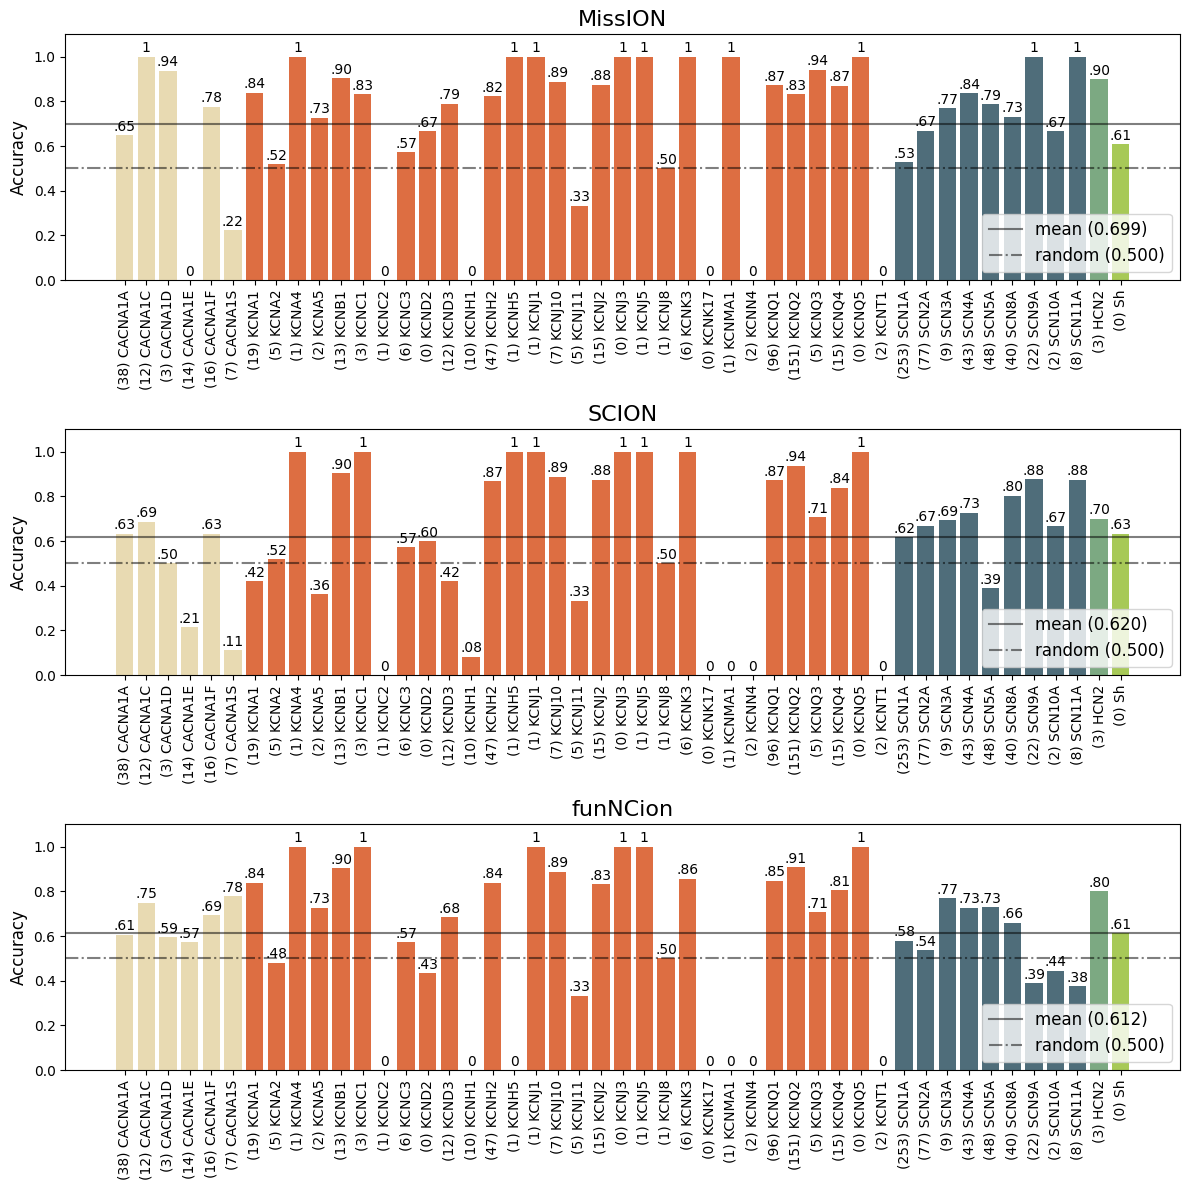

In [497]:
# === Sort genes for ordered plotting ===
genes_sorted = ['CACNA1A', 'CACNA1C', 'CACNA1D', 'CACNA1E', 'CACNA1F', 'CACNA1S', 
                'KCNA1', 'KCNA2', 'KCNA4', 'KCNA5', 'KCNB1', 'KCNC1', 'KCNC2', 'KCNC3', 
                'KCND2', 'KCND3', 'KCNH1', 'KCNH2', 'KCNH5', 'KCNJ1', 'KCNJ10', 'KCNJ11', 
                'KCNJ2', 'KCNJ3', 'KCNJ5', 'KCNJ8', 'KCNK3', 'KCNK17', 'KCNMA1', 'KCNN4', 
                'KCNQ1', 'KCNQ2', 'KCNQ3', 'KCNQ4', 'KCNQ5', 'KCNT1', 'SCN1A', 'SCN2A', 'SCN3A', 
                'SCN4A', 'SCN5A', 'SCN8A', 'SCN9A', 'SCN10A', 'SCN11A', 'HCN2', 'Sh']
no_hpo_genes = {'Sh', 'KCNQ5', 'KCNK17', 'KCNJ3', 'KCND2'}
no_hpo_genes_idx = np.array([1 if genes_sorted[i] in no_hpo_genes else 0 for i in range(len(genes_sorted))])

df = pd.read_csv('../Data/fixed_heyne.csv')
df = with_hpo_only(df)
temp = []
for g in genes_sorted:
    i = df.loc[df['gene'] == g].shape[0]
    x = f"({i}) {g}"
    temp.append(x)
genes_sorted_count = temp

# === Figure parameters ===
fontsize_legend = 12
fontsize_label = 12
fontsize_title=16
colors = ['#dd6e42', '#e8dab2', '#4f6d7a', '#a7c957', '#7ca982']

# === Plotting ===
# fig_size = (12, 8)
# fig, ax = plt.subplots(2, 1, figsize=fig_size, squeeze=False)
fig_size = (12, 12)
fig, ax = plt.subplots(3, 1, figsize=fig_size, squeeze=False)
ax = ax.flatten()

for i, (k, v) in enumerate(runs.items()):
    scores, genes = compute_metric(v, 'acc', 'micro', '(svm)' in k or '(gbm)' in k)
    
    bas_new = []
    for gg in genes_sorted:
        try:
            g_idx = genes.index(gg)
        except ValueError as e:
            g_idx = -1
            # raise e
        if g_idx == -1:
            bas_new.append(0)
        else:
            bas_new.append(scores[g_idx])
    scores = bas_new
    genes = genes_sorted

    
    cs = []
    for gg in genes:
        if 'KCN' in gg:
            color = colors[0]
        elif 'CACNA' in gg:
            color = colors[1]
        elif 'SCN' in gg:
            color = colors[2]
        elif 'Sh' in gg:
            color = colors[3]
        else:
            color = colors[4]
        cs.append(color)

    # exclusive_mean = np.nanmean(np.array(scores)[no_hpo_genes_idx])
    # ax[i].axhline(y=exclusive_mean, color='k', label=f'mean ({exclusive_mean:.3f})', alpha=0.5, linestyle='-')
    
    ax[i].axhline(y=np.nanmean(scores), color='k', label=f'mean ({np.nanmean(scores):.3f})', alpha=0.5, linestyle='-')

    
    ## Random model performance line
    # ax[idx].axhline(y=np.nanmean(random_model_scores, (0, 1)), color='k', linestyle='-.', label=f"random ({np.nanmean(random_model_scores, (0, 1)):.3f})", alpha=0.5)
    ax[i].axhline(y=0.5, color='k', linestyle='-.', label=f"random (0.500)", alpha=0.5)
    
    rect_ls = []
    rects = ax[i].bar(np.arange(len(genes)), scores, color=cs)
    ax[i].bar_label(rects, padding=1, fmt=custom_fmt)
    rect_ls.append(rects.datavalues)
    # ax[idx].set_ylabel(f'F1-score ({AVERAGE})', fontsize=fontsize_label)
    ax[i].set_ylabel(f'Accuracy', fontsize=fontsize_label)
    ax[i].set_title(k.replace('(svm)', '').replace('(gbm)', ''), fontsize=fontsize_title)
    
    ax[i].set_xticks(np.arange(len(genes)))
    ax[i].set_xticklabels(genes_sorted_count, ha='center')
    ax[i].tick_params(axis='x', rotation=90)
    ax[i].legend(loc=4, fontsize=fontsize_legend)
    
    ax[i].set_ylim([0, 1.1])


plt.tight_layout()

# save_fig(fig, 'Group_fold_mission_hpo_scion_mkl', fig_dir='./review_figures/', fig_fmt='png', fig_size=fig_size, transparent_png=False, dpi=300)


In [510]:
def miss_classified_count(folds):
    correct = []
    samples = []
    genes = []
    for fold in folds:
        be = fold.best_epoch
        p = np.argmax(fold.preds[be, :, :], 1)
        l = np.argmax(fold.labels[be], 1)
        varids = fold.varids[be]
        gene = varids[0].split('_')[0]
        genes.append(gene)

        s = sum(p == l)
        correct.append(s)
        samples.append(p.shape[0])

    return correct, samples, genes

correct, samples, genes = miss_classified_count(runs['MissION'])
pprint.pprint(list(zip(correct, samples, genes)))

sum(correct), sum(samples)

[(197, 373, 'SCN1A'),
 (237, 285, 'KCNQ2'),
 (46, 55, 'SCN4A'),
 (38, 49, 'CACNA1F'),
 (41, 41, 'SCN9A'),
 (30, 32, 'CACNA1D'),
 (27, 31, 'KCNQ4'),
 (20, 30, 'KCND2'),
 (14, 27, 'KCNA2'),
 (21, 24, 'KCNJ2'),
 (19, 21, 'KCNB1'),
 (15, 19, 'KCND3'),
 (119, 196, 'Sh'),
 (16, 17, 'KCNQ3'),
 (16, 16, 'CACNA1C'),
 (0, 14, 'CACNA1E'),
 (10, 13, 'SCN3A'),
 (4, 12, 'KCNJ11'),
 (0, 12, 'KCNH1'),
 (8, 11, 'KCNA5'),
 (9, 10, 'HCN2'),
 (6, 9, 'SCN10A'),
 (2, 9, 'CACNA1S'),
 (137, 157, 'KCNQ1'),
 (8, 9, 'KCNJ10'),
 (8, 8, 'SCN11A'),
 (7, 7, 'KCNK3'),
 (4, 7, 'KCNC3'),
 (5, 6, 'KCNC1'),
 (3, 3, 'KCNJ1'),
 (2, 2, 'KCNJ3'),
 (1, 2, 'KCNJ8'),
 (0, 2, 'KCNT1'),
 (0, 2, 'KCNN4'),
 (91, 136, 'SCN2A'),
 (1, 1, 'KCNQ5'),
 (0, 1, 'KCNK17'),
 (1, 1, 'KCNMA1'),
 (1, 1, 'KCNA4'),
 (0, 1, 'KCNC2'),
 (1, 1, 'KCNJ5'),
 (1, 1, 'KCNH5'),
 (67, 85, 'SCN5A'),
 (46, 71, 'CACNA1A'),
 (56, 68, 'KCNH2'),
 (52, 62, 'KCNA1'),
 (41, 56, 'SCN8A')]


(1428, 1996)

In [451]:
# runs['fake'] = fake_preds


In [452]:
overall_scores = {}
for i, (k, v) in enumerate(runs.items()):
    scores, genes = compute_metric(v, 'acc', 'micro', '(svm)' in k or '(gbm)' in k)
    bas_new = []
    for gg in genes_sorted:
        try:
            g_idx = genes.index(gg)
        except ValueError as e:
            g_idx = -1
            # raise e
        if g_idx == -1:
            bas_new.append(0)
        else:
            bas_new.append(scores[g_idx])
    s = bas_new
    overall_scores[k.replace('(svm)', '').replace('(gbm)', '')] = s

In [454]:
# for m1, m2 in combinations(overall_scores.keys(), 2):
#     # t_val, p_val = ttest_rel(overall_scores[m1], overall_scores[m2])
#     t_val, p_val = corrected_resampled_t_test(overall_scores[m1], overall_scores[m2], 1, 46)
#     print(f"{m1} vs. {m2}: t={t_val:.4f} p={p_val:.4f}")

data = pd.DataFrame(overall_scores)
# 2. Friedman Test
# stat, p = friedmanchisquare(*data.T)
stat, p = friedmanchisquare(data['MissION'], data['SCION'], data['funNCion'], axis=0)
print(f"Friedman={stat:.4f} P-value: {p:.4f}")

from scikit_posthocs import posthoc_nemenyi_friedman

n = posthoc_nemenyi_friedman(data.to_numpy())
n

Friedman=9.5556 P-value: 0.0084


,0,1,2,3
0,1.000000,0.475467,0.103403,0.971639
1,0.475467,1.000000,0.835923,0.750158
2,0.103403,0.835923,1.000000,0.255657
3,0.971639,0.750158,0.255657,1.000000


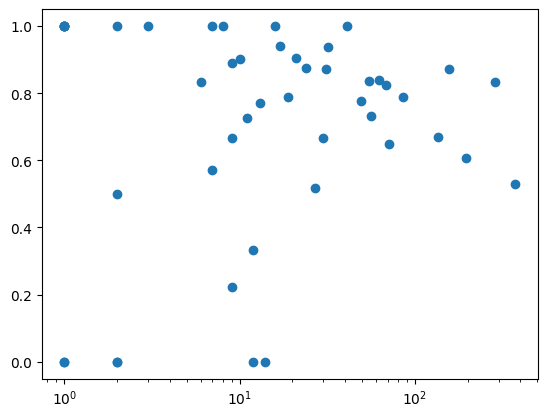

In [148]:

df = pd.read_csv("../Data/fixed_heyne.csv")
df = df[['VarID', 'gene', 'netChange']]

fig, ax = plt.subplots(1, 1, squeeze=False)

def compute_metric(folds: list[main2.Fold], metric='f1', average='weighted', svm=False):
    scores = []
    genes = []
    for fold_idx, fold in enumerate(folds):
        if not svm:
            genes.append(fold.varids[0][0].split('_')[0])
        else:
            genes.append(fold.varids[0].split('_')[0])
        be = fold.get_best_epoch()
        preds = fold.preds[be]
        labels = fold.labels[be]
        if preds.ndim > 1:
            l = np.argmax(labels, 1)
            p = np.argmax(preds, 1)
        else:
            l = labels
            p = preds
            p = (p > 0).astype(int)
        if metric == 'f1':
            score = f1_score(l, p, average=average, labels=[0, 1], pos_label=1, zero_division=np.nan)
        elif metric == 'acc':
            score = accuracy_score(l, p)
        elif metric == 'ba':
            # l = list(l) + [1, 1, 0, 0]
            # p = list(p) + [1, 0, 1, 0]
            score = balanced_accuracy_score(l, p)
        elif metric == 'mcc':
            score = matthews_corrcoef(l, p)
        elif metric == 'precision':
            precision = precision_score(l, p)
            recall = recall_score(l, p)
            score = (precision, recall)
        else: 
            raise Exception('unsupported metric')
        scores.append(score)
    return scores, genes

for i, (k, v) in enumerate(runs.items()):
    scores, genes = compute_metric(v, 'acc', 'macro', '(svm)' in k)
    # print(scores)
    # raise
    # print(genes)
    n_variants = []
    for gene in genes:
        c = df.loc[df['gene'] == gene].reset_index(drop=True)
        n_variants.append(c.shape[0])

    colors = []
    for gene in genes:
        if 'SCN' in gene:
            colors.append('blue')
        elif 'CACNA' in gene:
            colors.append('red')
        else:
            colors.append('green')
    ax[0, 0].scatter(n_variants, scores)#, color=colors)
    
    
    break

ax[0, 0].set_xscale('log', base=10)
plt.show()

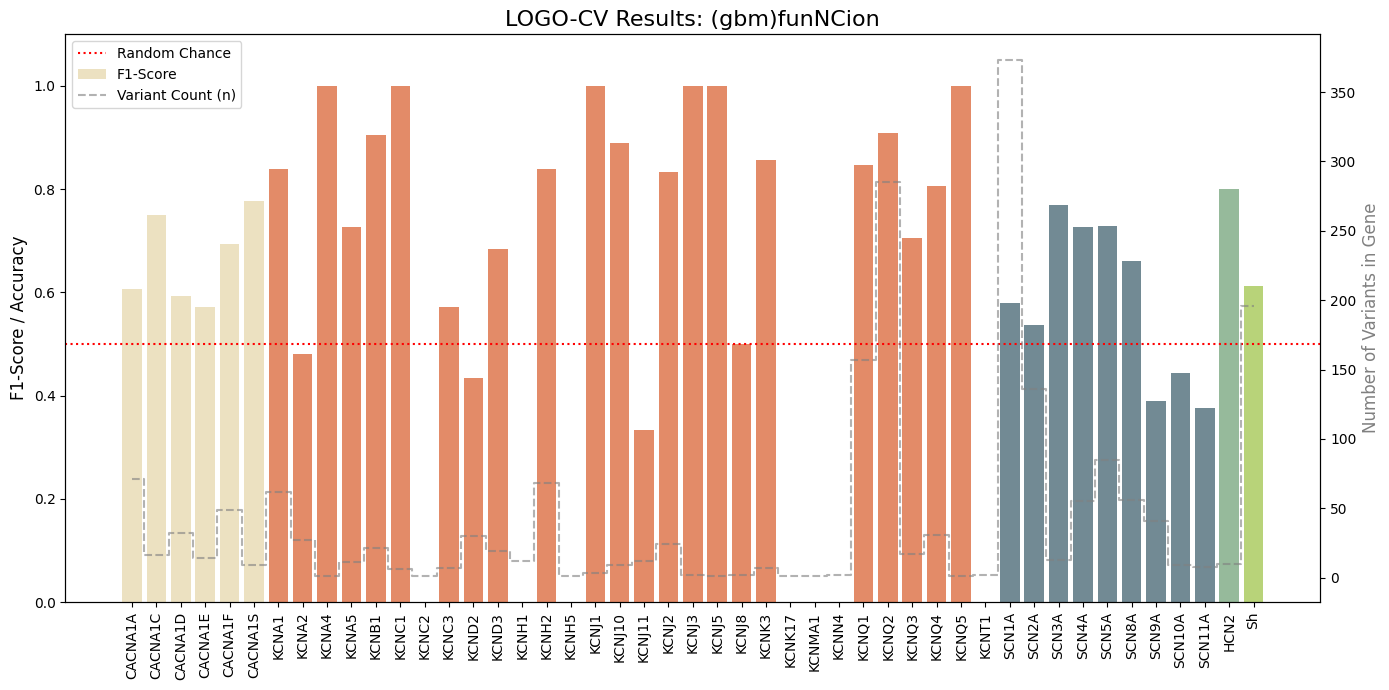

In [411]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot the scores
bars = ax1.bar(genes, scores, color=cs, alpha=0.8, label='F1-Score')

# Create a second y-axis for the sample size (n)
ax2 = ax1.twinx()
# Extract counts from your 'genes_sorted_count' strings
counts = [int(g.split('(')[1].split(')')[0]) for g in genes_sorted_count]
ax2.step(np.arange(len(genes)), counts, color='gray', where='mid', linestyle='--', alpha=0.6, label='Variant Count (n)')

# Formatting
ax1.set_ylabel('F1-Score / Accuracy', fontsize=12)
ax2.set_ylabel('Number of Variants in Gene', fontsize=12, color='gray')
ax1.set_ylim(0, 1.1)
ax1.set_title(f"LOGO-CV Results: {k}", fontsize=16)

# Add a "Chance" line
ax1.axhline(y=0.5, color='red', linestyle=':', label='Random Chance')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.xticks(rotation=90)
ax1.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

# Performance metrics table

ROC-AUC, PR-AUC, MCC, F1-weighted, F1-macro, F1-binary, Accuracy



In [66]:
def compute_metrics(folds, svm=False):
    scores = defaultdict(list)
    genes = []
    for fold_idx, fold in enumerate(folds):
        if not svm:
            genes.append(fold.varids[0][0].split('_')[0])
        else:
            genes.append(fold.varids[0].split('_')[0])
        be = fold.get_best_epoch()
        preds = fold.preds[be]
        labels = fold.labels[be]
        
        
        if preds.ndim > 1:
            gof_proba = preds[:, 1]
            pred_label = np.argmax(preds, 1)
            true_label = np.argmax(labels, 1)
        else:
            true_label = labels
            gof_proba = preds
            pred_label = (gof_proba > 0).astype(int)


        # # ROC AUC
        # scores['ROC-AUC'].append(
        #     roc_auc_score(true_label, gof_proba)
        # )

        # # precision, recall, _ = precision_recall_curve(true_label, gof_proba)
        # # scores['PR-AUC'].append(auc(recall, precision))

        # # Precision
        # scores['Precision'].append(
        #     precision_score(true_label, pred_label)
        # )
        # #Recall
        # scores['Recall'].append(
        #     recall_score(true_label, pred_label)
        # )
        # scores['PR-AUC'].append(
        #     average_precision_score(true_label, gof_proba)
        # )
        # # MCC
        # scores['MCC'].append(
        #     matthews_corrcoef(true_label, pred_label)
        # )
        # f1_averages = ['weighted', 'macro', 'binary']
        # for avg in f1_averages:
        #     scores[f'F1-{avg}'].append(
        #         f1_score(true_label, pred_label, labels=[0, 1], average=avg)
        #     )
        # # Accuracy
        scores['Accuracy'].append(
            accuracy_score(true_label, pred_label)
        )
        # Balanced Accuracy
        scores['BA'].append(
            balanced_accuracy_score(true_label, pred_label)
        )
    return scores
    
runs = {   
    # '1996': '1996_1180',
    'MissION': 'fixed_heyne_1',
    'ex. GO': 'Fixed_Heyne/3b_bf',
    'ex. BF': 'Fixed_Heyne/3b_go',
    'ex. ESM': 'Fixed_Heyne/go_bf',
    # '3b': 'Fixed_Heyne/esm3b',
    # 'go': 'Fixed_Heyne/go',
    # 'bf': 'Fixed_Heyne/bf',
    # 'hpo': 'Fixed_Heyne/hpo',
}
# # runs = {
# #     '3b': 'Fixed_Heyne/esm3b',
# #     '650': 'Fixed_Heyne/esm_650m',
# #     '150': 'Fixed_Heyne/esm_150m',
# #     '35': 'Fixed_Heyne/esm_35m',
# #     '8': 'Fixed_Heyne/esm_8m',
# # }
# runs = load_run_dict(runs)
# for k, v in runs.items():
#     print(f'----== {k} ==----')
#     scores = compute_metrics(v)
#     for k1, v1 in scores.items():
#         print(f"{k1}: {np.mean(v1):.4f}, {np.std(v1):.4f}")

# runs = {
#     'MissION': 'fixed_heyne_1',
#     '(gbm)funNCion': 'Out_v2/heyne_impute_scaler_output_rskf',
# }
runs = load_run_dict(runs)
for k, v in runs.items():
    print(f'----== {k} ==----')
    scores = compute_metrics(v, 'gbm' in k)
    for k1, v1 in scores.items():
        print(f"{k1}: {np.mean(v1):.4f}, {np.std(v1):.4f}")


> load_run :: 0.527 sec
> load_run :: 0.531 sec
> load_run :: 0.568 sec
> load_run :: 0.547 sec
----== MissION ==----
Accuracy: 0.8522, 0.0205
BA: 0.7979, 0.0285
----== ex. GO ==----
Accuracy: 0.8081, 0.0227
BA: 0.7358, 0.0418
----== ex. BF ==----
Accuracy: 0.8470, 0.0188
BA: 0.7856, 0.0269
----== ex. ESM ==----
Accuracy: 0.8447, 0.0214
BA: 0.7809, 0.0295


In [481]:
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.anova import AnovaRM
from itertools import combinations, permutations
from statsmodels.stats.multitest import multipletests


runs = {   
    'MissION': 'fixed_heyne_1',
    '3b': 'Fixed_Heyne/esm3b',
    'go': 'Fixed_Heyne/go',
    'bf': 'Fixed_Heyne/bf',
    'hpo': 'Fixed_Heyne/hpo',
}
runs = {   
    # '1996': '1996_1180',
    'MissION': 'fixed_heyne_1',
    'ex. GO': 'Fixed_Heyne/3b_bf',
    'ex. BF': 'Fixed_Heyne/3b_go',
    'ex. ESM': 'Fixed_Heyne/go_bf',
}
runs = load_run_dict(runs)

def ttest_fn():
    for k, v in runs.items():
        if k != 'MissION':
            model_scores = compute_metrics(v)
            print(f'---== {k} ==---')
            for metric_name in metric_names:
                # t_stat, p_value = ttest_rel(model_scores[metric_name], baseline_scores[metric_name])
                t_stat, p_value = wilcoxon(model_scores[metric_name], baseline_scores[metric_name])#, alternative='greater')
    
                # print(f"{k}: {t_stat:.4f} {p_value:.4e}")
                print(f"{metric_name}: {t_stat:.4f} {p_value:.4e}")

def metric_to_dataframe(runs, metric='PR-AUC') -> pd.DataFrame:
    x = []
    cols = []
    for k, v in runs.items():
        scores = compute_metrics(v)['PR-AUC']
        x.append(scores)
        cols.append(k)
    
    x = pd.DataFrame(x, index=cols).T
    return x

def anova_fn(metric_name = 'ROC-AUC'):
    df = []
    full_scores = {}
    for ki, (k, v) in enumerate(runs.items()):
        model_scores = compute_metrics(v)
        for f in range(len(model_scores[metric_name])):
            df.append(
            {
                'fold': f,
                'score': model_scores[metric_name][f],
                'model': k
            }
            )
        full_scores[k] = model_scores
    df = pd.DataFrame(df)
    print(df)
    
    anova = AnovaRM(df, depvar="score", subject="fold", within=["model"])
    result = anova.fit()
    print(result)

    # ====== Friedman ======

    xs = metric_to_dataframe(runs)
    xs = [xs[c] for c in xs.columns]
    stat, p = friedmanchisquare(*xs)
    print(f"Friedman={stat:.4f} P-value: {p:.4f}")
    
    models = df["model"].unique()
    pvals = []
    comparisons = []
    
    for m1, m2 in combinations(models, 2):
    # for m1, m2 in permutations(models, 2):
        s1 = df[df["model"] == m1]["score"].values
        s2 = df[df["model"] == m2]["score"].values
        
        # stat, p = ttest_rel(s1, s2, alternative='two-sided')
        stat, p = corrected_resampled_t_test(s1, s2, 3, 10)
        # stat, p = wilcoxon(s1, s2)
        pvals.append(p)
        comparisons.append((m1, m2))
    
    # Multiple testing correction
    reject, pvals_corr, _, _ = multipletests(pvals, method='holm')

    for (m1, m2), p, pc, r in zip(comparisons, pvals, pvals_corr, reject):
        print(f"{m1} vs {m2}: raw p={p:.4f}, corrected p={pc:.4f}, significant={r}")

    print('======= Mean differences =======')
    def cohens_d_paired(a, b):
        d = a - b
        return np.mean(d) / np.std(d, ddof=1)
    def summarize(name, a, b):
        diff = a - b
        return {
            "comparison": name,
            "mean_diff": np.mean(diff),
            "std_diff": np.std(diff, ddof=1),
            'cohens_d': cohens_d_paired(a, b)
        }
    for m1, m2 in combinations(models, 2):
    # for m1, m2 in permutations(models, 2):
        a = np.array(full_scores[m1][metric_name])
        b = np.array(full_scores[m2][metric_name])
        s = summarize(f"{m1} : {m2}", a, b)
        print(s)
        
anova_fn('PR-AUC')

> load_run :: 0.531 sec
> load_run :: 0.490 sec
> load_run :: 0.485 sec
> load_run :: 0.479 sec
     fold     score    model
0       0  0.875007  MissION
1       1  0.851595  MissION
2       2  0.772369  MissION
3       3  0.885594  MissION
4       4  0.856367  MissION
..    ...       ...      ...
115    25  0.853900  ex. ESM
116    26  0.787829  ex. ESM
117    27  0.783816  ex. ESM
118    28  0.849651  ex. ESM
119    29  0.858762  ex. ESM

[120 rows x 3 columns]
               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
model 90.2811 3.0000 87.0000 0.0000

Friedman=56.6800 P-value: 0.0000
MissION vs ex. GO: raw p=0.0000, corrected p=0.0000, significant=True
MissION vs ex. BF: raw p=0.1939, corrected p=0.5816, significant=False
MissION vs ex. ESM: raw p=0.3904, corrected p=0.7808, significant=False
ex. GO vs ex. BF: raw p=0.0000, corrected p=0.0000, significant=True
ex. GO vs ex. ESM: raw p=0.0000, corrected p=0.0001, significant=True
ex. BF vs ex. ESM

In [252]:
def corrected_resampled_t_test(scores1, scores2, n_repeats, n_folds):
    """
    Computes the Nadeau and Bengio Corrected Resampled t-test.
    """
    # 1. Calculate differences
    differences = np.array(scores1) - np.array(scores2)
    n = len(differences)  # Total number of observations (repeats * folds)
    
    # 2. Basic statistics
    mean_diff = np.mean(differences)
    var_diff = np.var(differences, ddof=1)
    
    # 3. Correction factor (rho)
    # rho = ratio of test samples to training samples
    # For 10-fold CV, test=1/10, train=9/10 -> rho = 1/9
    rho = 1 / (n_folds-1) 
    
    # 4. Corrected t-statistic
    # Variance is scaled by (1/n + rho)
    corrected_var = (1/n + rho) * var_diff
    t_stat = mean_diff / np.sqrt(corrected_var)
    
    # 5. P-value (Two-tailed)
    # Degrees of freedom is n - 1
    p_val = stats.t.sf(np.abs(t_stat), n-1) * 2
    
    return t_stat, p_val
    
def friedman_resampled_t_test(runs, metric='PR-AUC'):
    x = []
    cols = []
    for k, v in runs.items():
        s = compute_metrics(v)[metric]
        x.append(s)
        cols.append(k)
    data = pd.DataFrame(x, index=cols).T
    print(data.head(4))

    # 2. Friedman Test
    stat, p = friedmanchisquare(*data.T)
    print(f"Friedman P-value: {p:.4f}")

    pvals = []
    comparisons = []
    for m1, m2 in combinations(cols, 2):
        t_stat, p_val = corrected_resampled_t_test(data[m1], data[m2], 3, 10)
        pvals.append(p_val)
        comparisons.append((m1, m2, t_stat))
    
    reject, pvals_corr, _, _ = multipletests(pvals, method='holm')
    for (m1, m2, t_stat), p, pc, r in zip(comparisons, pvals, pvals_corr, reject):
        print(f"{m1} vs {m2}: t={t_stat:.4f}, raw p={p:.4f}, corrected p={pc:.4f}, significant={r}")

runs = {   
    'MissION': 'fixed_heyne_1',
    '3b': 'Fixed_Heyne/esm3b',
    'go': 'Fixed_Heyne/go',
    'bf': 'Fixed_Heyne/bf',
    'hpo': 'Fixed_Heyne/hpo',
}
runs = load_run_dict(runs)
friedman_resampled_t_test(runs, 'PR-AUC')

    MissION        3b        go        bf       hpo
0  0.875007  0.629272  0.817502  0.555472  0.542850
1  0.851595  0.635567  0.844787  0.503723  0.633983
2  0.772369  0.642666  0.729382  0.507003  0.564276
3  0.885594  0.659098  0.740773  0.633400  0.500526
Friedman P-value: 0.4651
MissION vs 3b: t=6.5509, raw p=0.0000, corrected p=0.0000, significant=True
MissION vs go: t=4.3203, raw p=0.0002, corrected p=0.0008, significant=True
MissION vs bf: t=11.1608, raw p=0.0000, corrected p=0.0000, significant=True
MissION vs hpo: t=9.3698, raw p=0.0000, corrected p=0.0000, significant=True
3b vs go: t=-2.7079, raw p=0.0112, corrected p=0.0337, significant=True
3b vs bf: t=4.0259, raw p=0.0004, corrected p=0.0015, significant=True
3b vs hpo: t=2.6531, raw p=0.0128, corrected p=0.0337, significant=True
go vs bf: t=6.9618, raw p=0.0000, corrected p=0.0000, significant=True
go vs hpo: t=7.6365, raw p=0.0000, corrected p=0.0000, significant=True
bf vs hpo: t=-1.5128, raw p=0.1412, corrected p=0.1

In [259]:
runs = {   
    # '1996': '1996_1180',
    'MissION': 'fixed_heyne_1',
    'ex. GO': 'Fixed_Heyne/3b_bf',
    'ex. BF': 'Fixed_Heyne/3b_go',
    'ex. ESM': 'Fixed_Heyne/go_bf',
}
runs = load_run_dict(runs)
def anova_fn(metric_name = 'ROC-AUC'):
    df = []
    for ki, (k, v) in enumerate(runs.items()):
        model_scores = compute_metrics(v)
        for f in range(len(model_scores[metric_name])):
            df.append(
            {
                'fold': f,
                'score': model_scores[metric_name][f],
                'model': k
            }
            )
    df = pd.DataFrame(df)
    print(df)

    xs = metric_to_dataframe(runs)
    xs = [xs[c] for c in xs.columns]
    stat, p = friedmanchisquare(*xs)
    print(f"Friedman={stat:.4f} P-value: {p:.4f}")
    
    anova = AnovaRM(df, depvar="score", subject="fold", within=["model"])
    result = anova.fit()
    
    print(result)

    models = df["model"].unique()
    pvals = []
    comparisons = []
    
    for m1, m2 in combinations(models, 2):
    # for m1, m2 in permutations(models, 2):
        s1 = df[df["model"] == m1]["score"].values
        s2 = df[df["model"] == m2]["score"].values
        
        stat, p = ttest_rel(s1, s2, alternative='two-sided')
        # stat, p = wilcoxon(s1, s2)
        pvals.append(p)
        comparisons.append((m1, m2))
    
    # Multiple testing correction
    reject, pvals_corr, _, _ = multipletests(pvals, method='holm')

    for (m1, m2), p, pc, r in zip(comparisons, pvals, pvals_corr, reject):
        print(f"{m1} vs {m2}: raw p={p:.4f}, corrected p={pc:.4f}, significant={r}")

anova_fn('PR-AUC')

> load_run :: 0.545 sec
> load_run :: 0.558 sec
> load_run :: 0.513 sec
> load_run :: 0.465 sec
     fold     score    model
0       0  0.875007  MissION
1       1  0.851595  MissION
2       2  0.772369  MissION
3       3  0.885594  MissION
4       4  0.856367  MissION
..    ...       ...      ...
115    25  0.853900  ex. ESM
116    26  0.787829  ex. ESM
117    27  0.783816  ex. ESM
118    28  0.849651  ex. ESM
119    29  0.858762  ex. ESM

[120 rows x 3 columns]
               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
model 90.2811 3.0000 87.0000 0.0000

MissION vs ex. GO: raw p=0.0000, corrected p=0.0000, significant=True
MissION vs ex. BF: raw p=0.0126, corrected p=0.0378, significant=True
MissION vs ex. ESM: raw p=0.0918, corrected p=0.1835, significant=False
ex. GO vs ex. BF: raw p=0.0000, corrected p=0.0000, significant=True
ex. GO vs ex. ESM: raw p=0.0000, corrected p=0.0000, significant=True
ex. BF vs ex. ESM: raw p=0.2585, corrected p=0.2585

NameError: name 'full_scores' is not defined

# Stacked confusion matrix plots

    This computes for each gene the confusion matrix. 
    These are then summed together to allow computing metrics across the full set of domains. 

    tn, fp
    fn, tp

    t|
    r|  tn, fp
    u|  fn, tp
    e|---------
      predicted

In [55]:
def compute_cm(folds: list[main2.Fold], svm = False):
    cms = {}
    for fold in folds: # each fold is a gene
        ps = []
        ls = []
        be = fold.best_epoch
        if not svm:
            gene = fold.varids[0][0].split('_')[0]
            p = np.argmax(fold.preds[be], 1)
            l = np.argmax(fold.labels[be], 1)
        else:
            gene = fold.varids[0].split('_')[0]
            p = fold.preds[be]
            p = (p > 0).astype(int)
            l = fold.labels[be]
        
        ps.extend(p)
        ls.extend(l)

        ls = np.array(ls)
        ps = np.array(ps)
        
        cm = confusion_matrix(ls, ps, labels=[0, 1])
        # tn, fp, fn, tp = confusion_matrix(ls, ps, labels=[0, 1]).ravel().tolist()
        cms[gene] = cm
    return cms

In [56]:
runs = {
    # 'MissION': 'group_fold_fixed_heyne',
    # 'MissION': 'fixed_heyne_group_fold', # Pre-split Data/data_splits/fixed_heyne_group_fold
    
    'MissION': 'fixed_heyne_group_fold_shuffled', # KFold_cv
    '(svm)SCION': 'group_fold_fixed_heyne_svm_decision_function',
    # '(gbm)funNCion': 'heyne_impute_scaler_output_gkf',
    '(gbm)funNCion': 'Out_v2/heyne_impute_scaler_output_gkf',

    # Group Fold with HPO
    # 'MissION': 'fixed_heyne_group_fold_hpo',
    # '(svm)SCION': 'fixed_heyne_group_fold_hpo',
}
runs = load_run_dict(runs)

> load_run :: 0.371 sec
> load_run :: 0.027 sec
> load_run :: 0.025 sec


In [57]:
for i, (k, v) in enumerate(runs.items()):
    print('==', k, '==')
    cm = compute_cm(v, '(svm)' in k or '(gbm)' in k)    

    scores = np.zeros((2, 2))
    for g, s in cm.items():
        scores += s
    print(scores)

    # plt.figure()
    # disp = ConfusionMatrixDisplay(scores)
    # disp.plot(values_format=f"")
    
    tn, fp, fn, tp = scores.ravel().tolist()
    mcc = (tp * tn - fp * fn) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    print(f'mcc: {mcc:.4f}')

    ppv = tp / (tp + fp) # Positive predictive value
    print(f'ppv: {ppv:.4f}')

    fdr = fp / (tp + fp) # False discovery rate
    print(f'fdr: {fdr:.4f}')

    p = tp + fn
    n = fp + tn
    tpr = tp / p
    tnr = tn / n
    ba = (tpr + tnr) / 2
    print(f'ba: {ba:.4f}')

    acc = (tp + tn) / (p + n)
    print(f'acc: {acc:.4f}')

    fpr = tp / n
    fnr = fn / p
    lrp = tpr / fpr
    lrn = fnr / tnr
    dor = lrp / lrn # Diagnostic odds ratio (higher is better)
    print(f'dor: {dor:.4f}')

    f1 = (2 * tp) / (2 * tp + fp + fn)
    print(f"f1: {f1:.4f}")

plt.show()

== MissION ==
[[1070.  354.]
 [ 214.  358.]]
mcc: 0.3561
ppv: 0.5028
fdr: 0.4972
ba: 0.6886
acc: 0.7154
dor: 5.0000
f1: 0.5576
== (svm)SCION ==
[[1106.  318.]
 [ 292.  280.]]
mcc: 0.2628
ppv: 0.4682
fdr: 0.5318
ba: 0.6331
acc: 0.6944
dor: 3.7877
f1: 0.4786
== (gbm)funNCion ==
[[1147.  277.]
 [ 367.  205.]]
mcc: 0.1731
ppv: 0.4253
fdr: 0.5747
ba: 0.5819
acc: 0.6774
dor: 3.1253
f1: 0.3890


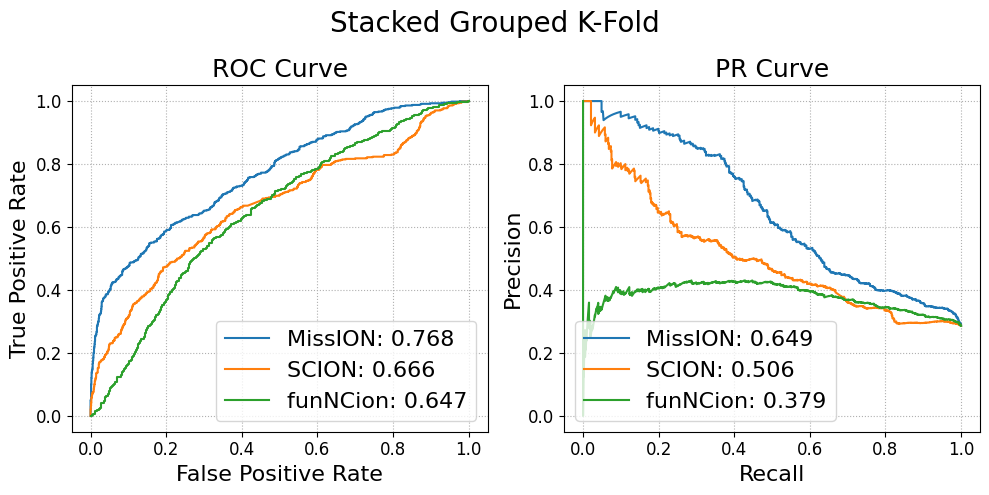

In [58]:
def compute_gf_roc(folds: list[main2.Fold], svm = False):
    ps = []
    ls = []
    for fold in folds:
        be = fold.best_epoch
        if not svm:
            p = fold.preds[be, :, 1]
            l = np.argmax(fold.labels[be], 1)
        else:
            p = fold.preds[be]
            l = fold.labels[be]
            
        ps.extend(p)
        ls.extend(l)

    fdr, tpr, threshold = roc_curve(ls, ps, pos_label=1)
    score = roc_auc_score(ls, ps)
    return fdr, tpr, threshold, score

def compute_gf_precision(folds: list[main2.Fold], svm=False):
    ps = []
    pt = []
    ls = []
    for fold in folds:
        be = fold.best_epoch
        if not svm:
            # p = np.argmax(fold.preds[be], 1)
            p = fold.preds[be, :, 1]
            pt.extend(np.argmax(fold.preds[be], 1))
            l = np.argmax(fold.labels[be], 1)
        else:
            p = fold.preds[be]
            pt.extend( (p>0).astype(int) )
            # p = (p > 0).astype(int)
            l = fold.labels[be]
            
        ps.extend(p)
        ls.extend(l)
        

    precision, recall, threshold = precision_recall_curve(ls, ps, pos_label=1)
    score = auc(recall, precision) # This is different from the next line
    # score = precision_score(ls, pt, pos_label=1) # This gives a weird result where the visually better model in the PR-Curve has a lower score
    return precision, recall, threshold, score

# fig, ax = plt.subplots(1, 2, figsize=(12,4.8))
fig_size = (10, 5)#4.8)
fig, ax = plt.subplots(1, 2, figsize=fig_size, tight_layout=True)

fontsize_title = 18
fontsize_suptitle = 20
fontsize_label = 16

# === ROC ===
for i, (k, v) in enumerate(runs.items()):
    fdr, tpr, _, score = compute_gf_roc(v, '(svm)' in k or '(gbm)' in k)
    
    ax[0].plot(fdr, tpr, label=f'{k.replace("(svm)", "").replace("(gbm)", "")}: {score:.3f}')
    ax[0].grid(linestyle=':')
    ax[0].legend(fontsize=fontsize_label)
    ax[0].set_title("ROC Curve", fontsize=fontsize_title)
    ax[0].set_xlabel("False Positive Rate", fontsize=fontsize_label)
    ax[0].set_ylabel("True Positive Rate", fontsize=fontsize_label)

# === Precision Recall ===
for i, (k, v) in enumerate(runs.items()):
    precision, recall, _, score = compute_gf_precision(v, '(svm)' in k or '(gbm)' in k)

    ax[1].plot(recall, precision, label=f"{k.replace('(svm)', '').replace('(gbm)', '')}: {score:.3f}")
    ax[1].grid(linestyle=':')
    ax[1].legend(fontsize=fontsize_label, loc=3)
    ax[1].set_title("PR Curve", fontsize=fontsize_title)
    ax[1].set_xlabel("Recall", fontsize=fontsize_label)
    ax[1].set_ylabel("Precision", fontsize=fontsize_label)

    # ax[1].set_ylim([-0.05, 1.05])

for i in [0, 1]:
    ax[i].tick_params(axis='x', labelsize=12)
    ax[i].tick_params(axis='y', labelsize=12)

plt.suptitle('Stacked Grouped K-Fold', fontsize=fontsize_suptitle)

# save_fig(fig, 'stacked_grouped_k_fold', fig_dir='./review_figures/', fig_fmt='pdf', fig_size=fig_size, transparent_png=False, dpi=300)

plt.show()

In [59]:
def stacked_metrics(folds, svm: bool = False):
    y_proba_ls = []
    y_preds_ls = []
    labels = []
    for fold in folds:
        be = fold.best_epoch
        if not svm:
            preds = fold.preds[be, :, :]
            y_proba = preds[:, 1]
            y_preds = np.argmax(preds, 1)
            label = np.argmax(fold.labels[be], 1)
        else:
            preds = fold.preds[be]
            y_proba = preds
            y_preds = (y_proba > 0).astype(int)
            label = fold.labels[be]

        labels.extend(label)
        y_proba_ls.extend(y_proba)
        y_preds_ls.extend(y_preds)

    y_proba_ls = np.array(y_proba_ls)
    y_preds_ls = np.array(y_preds_ls)
    labels = np.array(labels)

    true_label = labels
    gof_proba = y_proba_ls
    pred_label = y_preds_ls

    # Metrics 
    scores = defaultdict(list)
    scores['ROC-AUC'].append(
        roc_auc_score(true_label, gof_proba)
    )
    
    # Precision
    scores['Precision'].append(
        precision_score(true_label, pred_label)
    )
    #Recall
    scores['Recall'].append(
        recall_score(true_label, pred_label)
    )
    scores['PR-AUC'].append(
        average_precision_score(true_label, gof_proba)
    )
    # MCC
    scores['MCC'].append(
        matthews_corrcoef(true_label, pred_label)
    )
    f1_averages = ['weighted', 'macro', 'binary']
    for avg in f1_averages:
        scores[f'F1-{avg}'].append(
            f1_score(true_label, pred_label, labels=[0, 1], average=avg)
        )
    # Accuracy
    scores['Accuracy'].append(
        accuracy_score(true_label, pred_label)
    )
    # Balanced Accuracy
    scores['BA'].append(
        balanced_accuracy_score(true_label, pred_label)
    )

    # False positives
    fp = np.sum((pred_label == 1) & (true_label == 0))
    tn_plus_fp = np.sum(true_label == 0)
    fpr = fp / tn_plus_fp
    scores['FP'].append(
        fpr
    )

    return scores

def stacked_metrics_by_group(folds, groups: [str], svm: bool = False):
    gs = []
    for group in groups:
        g = group.split(',')
        gs.extend(g)

    y_proba_ls = []
    y_preds_ls = []
    labels = []
    for fold in folds:
        be = fold.best_epoch
        if not svm:
            gene = fold.varids[be][0].split('_')[0]
        else:
            gene = fold.varids[0][0].split('_')[0]
        if gene not in gs:
            continue
        
        if not svm:
            preds = fold.preds[be, :, :]
            y_proba = preds[:, 1]
            y_preds = np.argmax(preds, 1)
            label = np.argmax(fold.labels[be], 1)
        else:
            preds = fold.preds[be]
            y_proba = preds
            y_preds = (y_proba > 0).astype(int)
            label = fold.labels[be]

        labels.extend(label)
        y_proba_ls.extend(y_proba)
        y_preds_ls.extend(y_preds)

    y_proba_ls = np.array(y_proba_ls)
    y_preds_ls = np.array(y_preds_ls)
    labels = np.array(labels)

    true_label = labels
    gof_proba = y_proba_ls
    pred_label = y_preds_ls

    scores = defaultdict(list)
    # scores['PR-AUC'].append(
    #     average_precision_score(true_label, gof_proba)
    # )
    scores['Acc'].append(
        accuracy_score(true_label, pred_label)
    )
    return scores

subsets = [
    'KCNQ2, KCNQ3, KCNA4, KCNQ5, KCNH5, KCNQ4, KCNMA1, KCNN4, HCN2, SH, KCNB1, KCNA1, KCNH1, KCND2, KCND3, KCNC1, KCNC2, KCNA2, KCNC3'
    'KCNT1, KCNK17',
    'KCNJ11, KCNJ8, KCNJ1, KCNJ10, KCNJ3, KCNJ5, KCNA5, SCN5A, KCNJ2, KCNH2, KCNQ1',
    'CACNA1A, CACNA1E, CACNA1F, CACNA1S, CACNA1C, CACNA1D',
    'SCN11A, SCN9A, SCN3A, SCN4A, SCN2A, SCN8A, SCN10A, SCN1A'
]
# k = 'MissION'
# v = runs[k]
# print(k, stacked_metrics_by_group(v, subsets[0:1], False))
# print(k, stacked_metrics_by_group(v, subsets[0:2], False))
# print(k, stacked_metrics_by_group(v, subsets[0:3], False))
# print(k, stacked_metrics_by_group(v, subsets[0:4], False))


for k, v in runs.items():
    is_svm = 'svm' in k or 'gbm' in k
    print(k, stacked_metrics(v, is_svm))
    print()


MissION defaultdict(<class 'list'>, {'ROC-AUC': [0.767904234108588], 'Precision': [0.5028089887640449], 'Recall': [0.6258741258741258], 'PR-AUC': [0.6493846061178283], 'MCC': [0.35611699129723745], 'F1-weighted': [0.7235888324825818], 'F1-macro': [0.6739417532912749], 'F1-binary': [0.557632398753894], 'Accuracy': [0.7154308617234469], 'BA': [0.6886393101280741], 'FP': [0.24859550561797752]})

(svm)SCION defaultdict(<class 'list'>, {'ROC-AUC': [0.6662091419816139], 'Precision': [0.4682274247491639], 'Recall': [0.48951048951048953], 'PR-AUC': [0.5066582132759998], 'MCC': [0.26275450165673503], 'F1-weighted': [0.696376610217048], 'F1-macro': [0.6312368629873946], 'F1-binary': [0.47863247863247865], 'Accuracy': [0.6943887775551102], 'BA': [0.6330979413844583], 'FP': [0.22331460674157302]})

(gbm)funNCion defaultdict(<class 'list'>, {'ROC-AUC': [0.6470188870118645], 'Precision': [0.42531120331950206], 'Recall': [0.3583916083916084], 'PR-AUC': [0.3802799482373036], 'MCC': [0.1731265670862398

In [811]:
def stacked_metrics(folds, svm: bool = False):
    y_proba_ls = []
    y_preds_ls = []
    labels = []
    out = []
    for fold in folds:
        be = fold.best_epoch
        if not svm:
            preds = fold.preds[be, :, :]
            y_proba = preds[:, 1]
            y_preds = np.argmax(preds, 1)
            label = np.argmax(fold.labels[be], 1)
            varids = fold.varids[be]
            gene = varids[0].split('_')[0]
        else:
            preds = fold.preds[0]
            y_proba = preds
            y_preds = (y_proba > 0).astype(int)
            label = fold.labels[0]
            varids = fold.varids
            gene = varids[0].split('_')[0]

        labels.extend(label)
        y_proba_ls.extend(y_proba)
        y_preds_ls.extend(y_preds)
        
        for i, v in enumerate(varids):
            out.append({
                'VarID': v,
                'Label': label[i],
                'Pred': y_preds[i],
                'Proba_gof': y_proba[i]
            })

        goi = 'SCN2A'
        if gene == goi:
            print(f'{goi} gof preds:', sum(y_preds), '/', len(label), f"({sum(label)})")
            print(np.mean(y_proba), np.max(y_proba))

    return pd.DataFrame(out)

out = stacked_metrics(runs['MissION'])
print(sum(out['Label'] == out['Pred']))
print(out.shape)

SCN2A gof preds: 110 / 136 (79)
0.6673494360377361 0.9391365537751081
1428
(1996, 4)


In [812]:
out = stacked_metrics(runs['(svm)SCION'], True)
print(sum(out['Label'] == out['Pred']))
print(out.shape)

SCN2A gof preds: 96 / 136 (79)
0.2155533655960107 1.2403761838979415
1386
(1996, 4)


In [813]:
out = stacked_metrics(runs['(gbm)funNCion'], True)
print(sum(out['Label'] == out['Pred']))
print(out.shape)

SCN2A gof preds: 54 / 136 (79)
-0.4952473957940466 3.506117334493542
1373
(1996, 4)


In [814]:
df = pd.read_csv("../Data/fixed_heyne.csv")[['VarID', 'gene', 'netChange']]
df_gb = df.groupby('gene')['netChange'].value_counts()
print(df_gb)
df_gb.to_csv('group_fold_by_netChange.csv')
# df_gb['KCNQ4']

gene     netChange
CACNA1A  lof           45
         gof           26
CACNA1C  gof           16
CACNA1D  gof           32
CACNA1E  gof           14
                     ... 
SCN8A    gof           50
         lof            6
SCN9A    gof           41
Sh       lof          124
         gof           72
Name: count, Length: 73, dtype: int64


Mantel Correlation Coefficient (r): 0.0443
P-value: 0.2420
------- ------- -------
--- TF-IDF Weighted Mantel Test ---
Correlation (r): 0.0574
P-value: 0.0760


/home/sean/.pyenv/versions/3.9.16/envs/esmpy/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/sean/.pyenv/versions/3.9.16/envs/esmpy/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1600x1600 with 0 Axes>

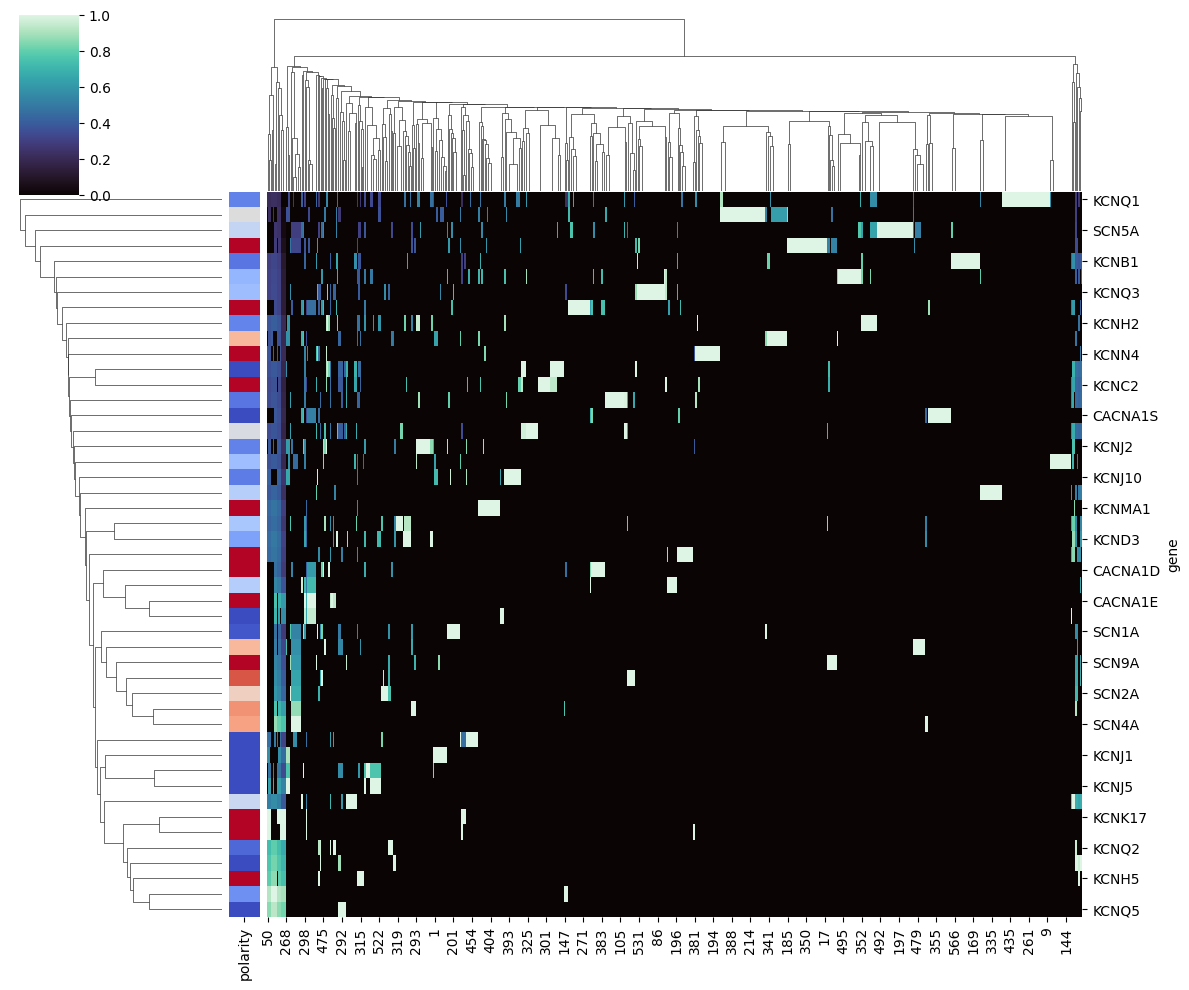

In [815]:
from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import mantel # Requires: pip install scikit-bio
from sklearn.feature_extraction.text import TfidfTransformer
from scipy.spatial.distance import pdist
from skbio.stats.distance import mantel

def go_similiarity_score(gof_polarity: bool =True):
    df = pd.read_csv("../Data/fixed_heyne.csv")[['VarID', 'gene', 'netChange', 'GOTerms']]
    df = encode_go_terms(df)

    if gof_polarity:
        gof_counts = (df['netChange'] == 'gof').groupby(df['gene']).sum()
        total_counts = df.groupby('gene').size()
        polarity = gof_counts / total_counts
    else:
        gof_counts = (df['netChange'] == 'gof').groupby(df['gene']).sum()
        lof_counts = (df['netChange'] == 'lof').groupby(df['gene']).sum()
        max_counts = gof_counts.combine(lof_counts, max)  # <-- fix
        total_counts = df.groupby('gene').size()
        polarity = max_counts / total_counts
        
    df['polarity'] = df['gene'].map(polarity)

    return df

def run_mantel_analysis(df):
    # 1. Collapse to Gene Level
    # We take the mean of GO terms (which are 0/1) and the polarity score
    # This ensures each gene is represented once.
    go_columns = [col for col in df.columns if col.startswith('GO:')] # Adjust prefix if needed)
    gene_summary = df.groupby('gene').agg({
        **{col: 'first' for col in go_columns},
        'polarity': 'first'
    })

    # --- NEW: CRITICAL STEP ---
    # Convert GO columns to float to avoid "Unsupported dtype object"
    gene_summary[go_columns] = gene_summary[go_columns].apply(pd.to_numeric, errors='coerce').fillna(0)
    # --------------------------
    
    # 2. Compute the GO Similarity Matrix
    # Using Jaccard distance is ideal for binary GO terms
    go_dist_matrix = pdist(gene_summary[go_columns], metric='jaccard')
    
    # 3. Compute the Polarity Distance Matrix
    # Using Euclidean distance for the continuous polarity score (0.0 to 1.0)
    # We reshape to 2D for pdist
    polarity_values = gene_summary['polarity'].values.reshape(-1, 1)
    polarity_dist_matrix = pdist(polarity_values, metric='euclidean')

    # 4. Perform the Mantel Test
    # This correlates the two matrices and uses permutations for a p-value
    coeff, p_value, n = mantel(go_dist_matrix, polarity_dist_matrix, permutations=999)

    print(f"Mantel Correlation Coefficient (r): {coeff:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    #return coeff, p_value

def run_tfidf_mantel(df):
    # 1. Identify GO columns and Aggregate to Gene Level
    go_columns = [col for col in df.columns if col.startswith('GO:')]
    gene_summary = df.groupby('gene').agg({
        **{col: 'first' for col in go_columns},
        'polarity': 'first'
    })
    
    # Ensure numeric conversion (fix for the previous error)
    go_matrix = gene_summary[go_columns].apply(pd.to_numeric, errors='coerce').fillna(0).values

    # 2. Apply TF-IDF Weighting
    # This transforms your 0/1 binary matrix into a weighted importance matrix
    tfidf = TfidfTransformer()
    weighted_go_matrix = tfidf.fit_transform(go_matrix).toarray()

    # 3. Compute Distance Matrices
    # Note: For weighted continuous data, Cosine or Euclidean is better than Jaccard
    go_dist_matrix = pdist(weighted_go_matrix, metric='cosine')
    
    polarity_values = gene_summary['polarity'].values.reshape(-1, 1)
    polarity_dist_matrix = pdist(polarity_values, metric='euclidean')

    # 4. Mantel Test
    coeff, p_value, n = mantel(go_dist_matrix, polarity_dist_matrix, permutations=999)

    print(f"--- TF-IDF Weighted Mantel Test ---")
    print(f"Correlation (r): {coeff:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    return coeff, p_value, gene_summary, weighted_go_matrix

df = go_similiarity_score(True)
run_mantel_analysis(df)
print('------- ------- -------')
coeff, p_val, gene_summary, weighted_matrix = run_tfidf_mantel(df)

def plot_gene_clusters(gene_summary, weighted_matrix):
    # Create a dataframe for the weighted terms
    weighted_df = pd.DataFrame(weighted_matrix, index=gene_summary.index)

    plt.figure(figsize=(16, 16))
    # Map polarity to a color scale for the sidebar
    # Red = 1.0 (All GOF), Blue = 0.0 (All LOF)
    lut = sns.color_palette("coolwarm", len(gene_summary))
    row_colors = gene_summary['polarity'].map(lambda x: sns.color_palette("coolwarm", as_cmap=True)(x))

    g = sns.clustermap(weighted_df, 
                       cmap="mako", 
                       row_colors=row_colors, 
                       figsize=(12, 10),
                       standard_scale=1) # Scale columns to see patterns better
    # plt.savefig('./mantel_cluster.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_gene_clusters(gene_summary, weighted_matrix)

--- Functional Cluster Analysis ---
Kruskal-Wallis Statistic: 9.7682
P-value: 0.2021
Result: No significant difference found between these clusters.


/tmp/ipykernel_11030/1028967715.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='polarity', data=gene_summary, palette='Set2')


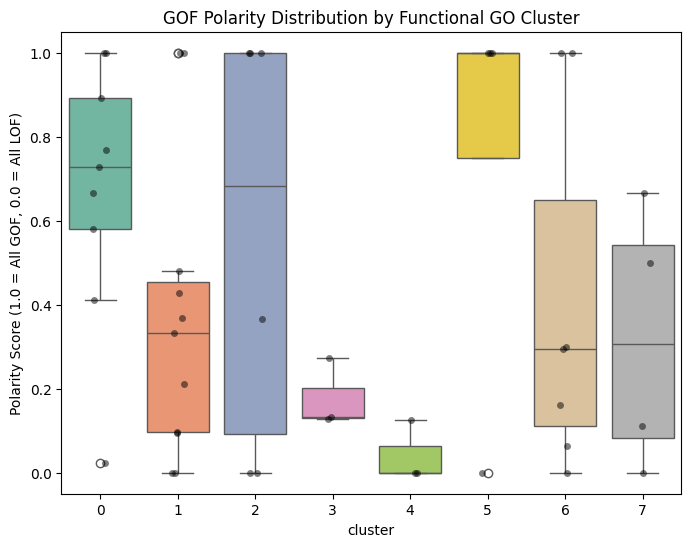

In [834]:
from sklearn.cluster import KMeans
from scipy.stats import kruskal

def cluster_and_test_polarity(df, n_clusters=3):
    # 1. Prepare Gene-Level TF-IDF Data
    go_columns = [col for col in df.columns if col.startswith('GO:')]
    gene_summary = df.groupby('gene').agg({
        **{col: 'first' for col in go_columns},
        'polarity': 'first'
    })
    
    go_matrix = gene_summary[go_columns].apply(pd.to_numeric, errors='coerce').fillna(0).values
    tfidf = TfidfTransformer()
    weighted_matrix = tfidf.fit_transform(go_matrix).toarray()

    # 2. Perform K-Means Clustering
    # We group genes based ONLY on their GO similarities
    kmeans = KMeans(n_clusters=n_clusters, random_state=404, n_init=10)
    gene_summary['cluster'] = kmeans.fit_predict(weighted_matrix)

    # 3. Kruskal-Wallis Test
    # Compare Polarity Scores across the identified clusters
    groups = [gene_summary[gene_summary['cluster'] == i]['polarity'].values 
              for i in range(n_clusters)]
    
    stat, p_value = kruskal(*groups)
    
    print(f"--- Functional Cluster Analysis ---")
    print(f"Kruskal-Wallis Statistic: {stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print("Result: Significant difference in GOF/LOF distribution between functional clusters!")
    else:
        print("Result: No significant difference found between these clusters.")

    # 4. Visualization: Boxplot of Polarity by Cluster
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='cluster', y='polarity', data=gene_summary, palette='Set2')
    sns.stripplot(x='cluster', y='polarity', data=gene_summary, color='black', alpha=0.5)
    plt.title('GOF Polarity Distribution by Functional GO Cluster')
    plt.ylabel('Polarity Score (1.0 = All GOF, 0.0 = All LOF)')
    plt.show()

    return gene_summary, go_columns

df = go_similiarity_score(True)
gene_summary, go_columns = cluster_and_test_polarity(df, 8)

In [835]:
def get_cluster_descriptors(gene_summary, go_columns, n_top_terms=5):
    # Calculate the mean TF-IDF weight per GO term for each cluster
    for cluster_id in gene_summary['cluster'].unique():
        cluster_genes = gene_summary[gene_summary['cluster'] == cluster_id]
        # Get the average weights for this cluster
        top_terms = cluster_genes[go_columns].mean().sort_values(ascending=False).head(n_top_terms)
        
        print(f"\nCluster {cluster_id} is characterized by:")
        for term, score in top_terms.items():
            print(f" - {term} (Weight: {score:.3f})")
        print(f" Genes in this cluster: {', '.join(cluster_genes.index.tolist())}")

get_cluster_descriptors(gene_summary, go_columns)


Cluster 2 is characterized by:
 - GO:0005216 (Weight: 1.000)
 - GO:0046872 (Weight: 1.000)
 - GO:0005891 (Weight: 1.000)
 - GO:0006811 (Weight: 1.000)
 - GO:0006816 (Weight: 1.000)
 Genes in this cluster: CACNA1A, CACNA1C, CACNA1D, CACNA1E, CACNA1F, CACNA1S

Cluster 6 is characterized by:
 - GO:0071805 (Weight: 1.000)
 - GO:0016020 (Weight: 1.000)
 - GO:0034220 (Weight: 1.000)
 - GO:0006813 (Weight: 1.000)
 - GO:0005249 (Weight: 1.000)
 Genes in this cluster: HCN2, KCNH5, KCNMA1, KCNQ2, KCNQ3, KCNQ4, KCNQ5

Cluster 1 is characterized by:
 - GO:0042995 (Weight: 1.000)
 - GO:0016020 (Weight: 1.000)
 - GO:0055085 (Weight: 1.000)
 - GO:0005886 (Weight: 1.000)
 - GO:0005267 (Weight: 1.000)
 Genes in this cluster: KCNA1, KCNA2, KCNA4, KCNB1, KCNC1, KCNC2, KCNC3, KCND2, KCND3, KCNH1, Sh

Cluster 3 is characterized by:
 - GO:0086091 (Weight: 1.000)
 - GO:0008076 (Weight: 1.000)
 - GO:0005251 (Weight: 1.000)
 - GO:0005267 (Weight: 1.000)
 - GO:0005515 (Weight: 1.000)
 Genes in this cluster: KC

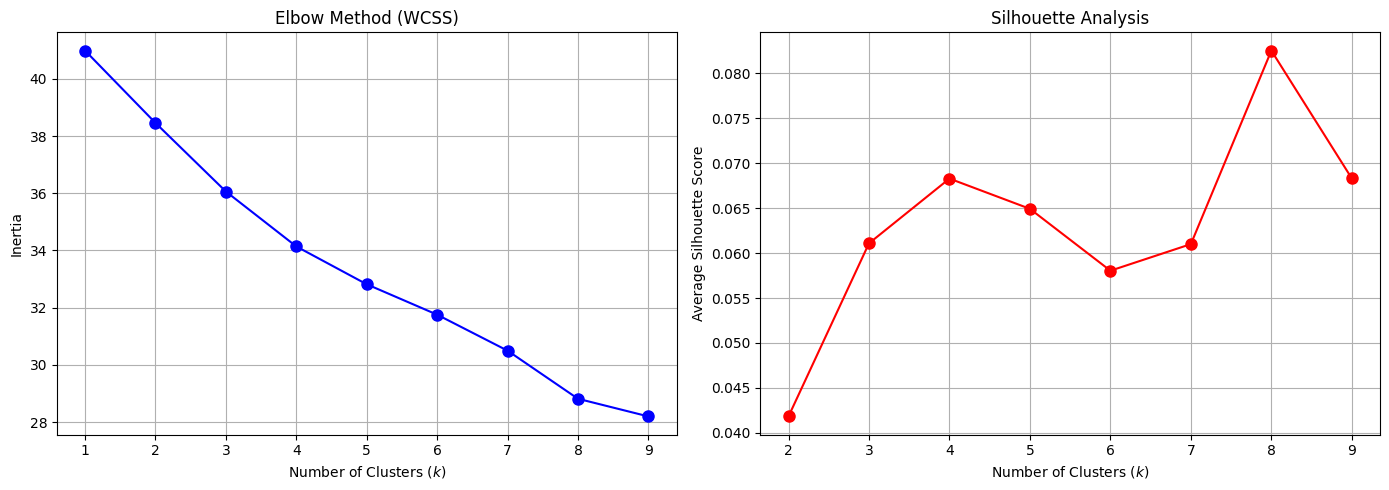

In [818]:
from sklearn.metrics import silhouette_score

def run_optimization_tests(df, max_k=10):
    # 1. Prepare Data
    go_columns = [col for col in df.columns if col.startswith('GO:')]
    gene_summary = df.groupby('gene').agg({
        **{col: 'first' for col in go_columns},
        'polarity': 'first'
    })
    
    # Weighting
    go_matrix = gene_summary[go_columns].apply(pd.to_numeric, errors='coerce').fillna(0).values
    weighted_matrix = TfidfTransformer().fit_transform(go_matrix).toarray()

    # 2. Compute Metrics
    wcss = []
    sil_scores = []
    # Cap k at the number of genes minus 1
    k_limit = min(max_k, len(gene_summary))
    k_range = range(2, k_limit) 

    # WCSS needs to start at 1 to see the full curve
    for k in range(1, k_limit):
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(weighted_matrix)
        wcss.append(km.inertia_)
        
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(weighted_matrix)
        sil_scores.append(silhouette_score(weighted_matrix, labels))

    # 3. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Elbow Plot
    ax1.plot(range(1, k_limit), wcss, 'bo-', markersize=8)
    ax1.set_title('Elbow Method (WCSS)')
    ax1.set_xlabel('Number of Clusters ($k$)')
    ax1.set_ylabel('Inertia')
    ax1.grid(True)

    # Silhouette Plot
    ax2.plot(k_range, sil_scores, 'ro-', markersize=8)
    ax2.set_title('Silhouette Analysis')
    ax2.set_xlabel('Number of Clusters ($k$)')
    ax2.set_ylabel('Average Silhouette Score')
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('cluster_optimization.png')
    plt.show()

run_optimization_tests(df, 10)

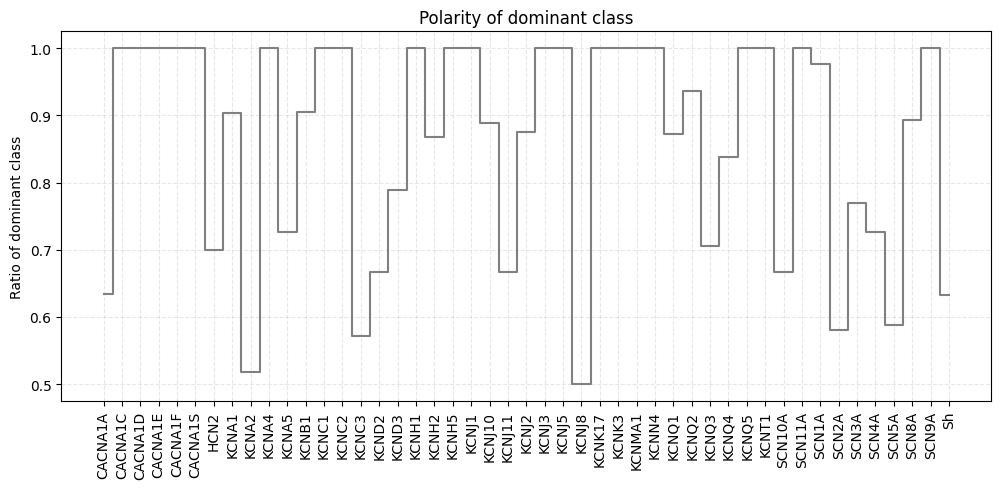

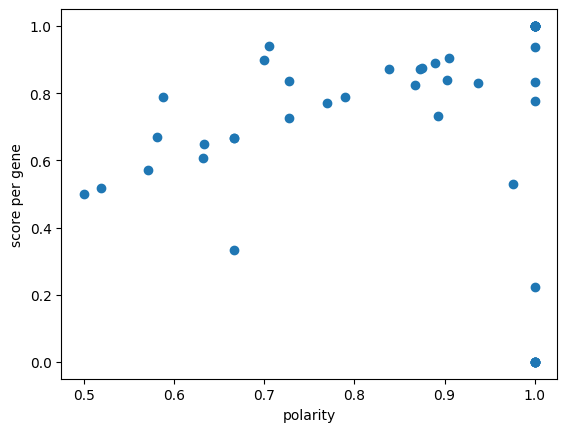

In [819]:
df = go_similiarity_score(False)
polarity_vec = df.groupby('gene')['polarity'].mean()
xlabels = list(polarity_vec.index)
plt.figure(figsize=(12, 4.8))
# plt.bar(range(len(polarity_vec)), polarity_vec)
plt.step(range(len(polarity_vec)), polarity_vec, color='gray', where='mid', linestyle='-', alpha=1, label='Variant Count (n)')

plt.xticks(ticks = range(len(xlabels)), labels=xlabels, rotation=90)

plt.grid(linestyle='--', alpha=0.3)
plt.title('Polarity of dominant class')
plt.ylabel('Ratio of dominant class')
plt.show()

def score_per_gene(folds):
    out = []
    for fold in folds:
        be = fold.best_epoch
        preds = np.argmax(fold.preds[be, :, :], 1)
        label = np.argmax(fold.labels[be], 1)
        varids = fold.varids[be]
        for i, varid in enumerate(varids):
            out.append({
                'VarID': varid,
                'gene': varid.split('_')[0],
                'Correct': (preds[i] == label[i]).astype(int),
            })
    return pd.DataFrame(out)

df_scores_per_gene = score_per_gene(runs['MissION'])
        
df_scores_per_gene_mean = df_scores_per_gene.groupby('gene')['Correct'].mean()    
        
plt.figure()
plt.scatter(polarity_vec, df_scores_per_gene_mean)
plt.ylabel('score per gene')
plt.xlabel('polarity')
plt.show()

./review_figures/pdf/go_term_hierarchy_cluster.pdf


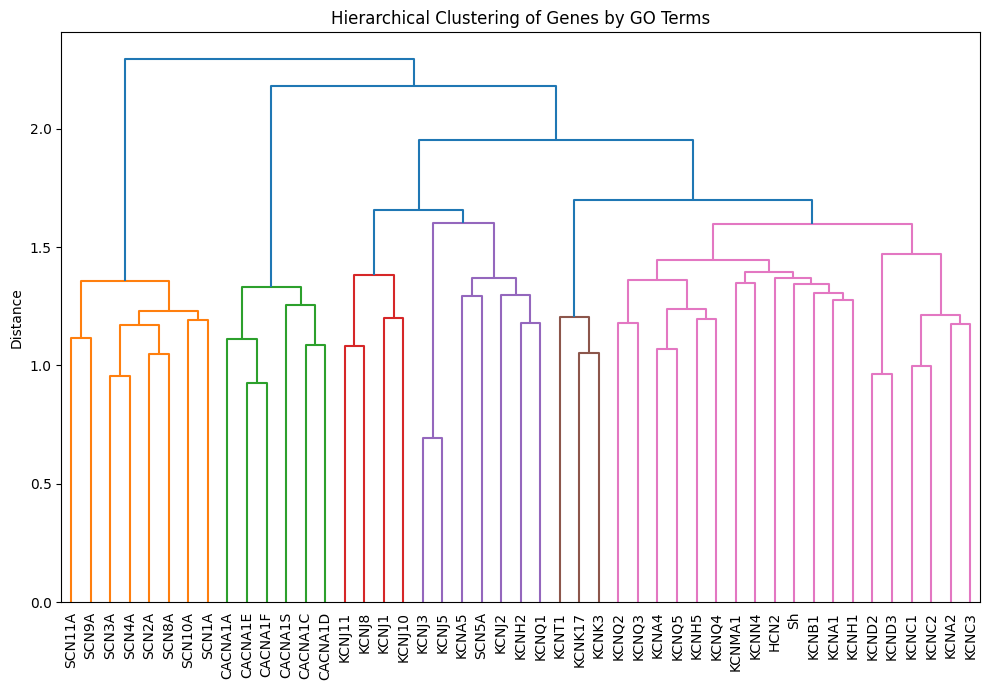

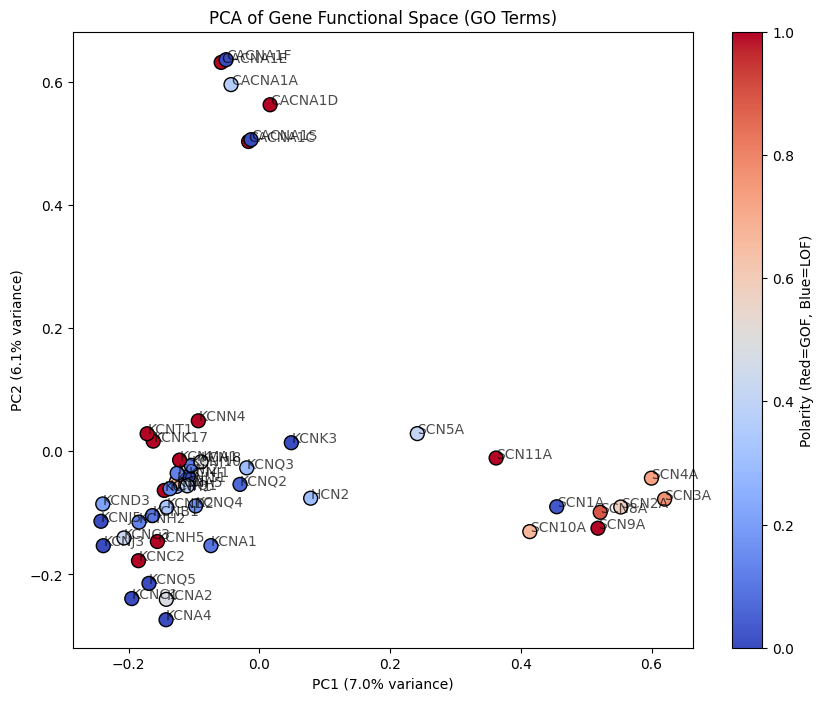

In [829]:
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import PCA

def plot_gene_dendrogram(df):
    # 1. Prepare Data
    go_columns = [col for col in df.columns if col.startswith('GO:')]
    gene_summary = df.groupby('gene').agg({
        **{col: 'first' for col in go_columns},
        'polarity': 'first'
    })
    
    go_matrix = gene_summary[go_columns].apply(pd.to_numeric).fillna(0).values
    weighted_matrix = TfidfTransformer().fit_transform(go_matrix).toarray()

    # 2. Compute Linkage (Ward's method minimizes variance within clusters)
    # We use 'cosine' distance because TF-IDF vectors are better compared by angle
    linkage_matrix = sch.linkage(weighted_matrix, method='ward')

    # 3. Plot Dendrogram
    fig_size = (10, 7)
    fig = plt.figure(figsize=fig_size)
    dendro = sch.dendrogram(
        linkage_matrix, 
        labels=gene_summary.index, 
        leaf_rotation=90,
        leaf_font_size=10
    )
    plt.title("Hierarchical Clustering of Genes by GO Terms")
    plt.ylabel("Distance")
    plt.tight_layout()
    save_fig(fig, 'go_term_hierarchy_cluster', fig_dir='./review_figures/', fig_fmt='pdf', fig_size=fig_size, transparent_png=False, dpi=300)
    plt.show()

    return linkage_matrix

def plot_pca_functional_space(df):
    # Prepare weighted matrix (as above)
    go_columns = [col for col in df.columns if col.startswith('GO:')]
    gene_summary = df.groupby('gene').agg({**{c: 'first' for c in go_columns}, 'polarity': 'first'})
    weighted_matrix = TfidfTransformer().fit_transform(gene_summary[go_columns]).toarray()

    # Reduce to 2D
    pca = PCA(n_components=2)
    components = pca.fit_transform(weighted_matrix)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(components[:, 0], components[:, 1], 
                         c=gene_summary['polarity'], 
                         cmap='coolwarm', s=100, edgecolors='black')
    
    # Annotate gene names
    for i, gene in enumerate(gene_summary.index):
        plt.annotate(gene, (components[i, 0], components[i, 1]), alpha=0.7)
        
    plt.colorbar(scatter, label='Polarity (Red=GOF, Blue=LOF)')
    plt.title("PCA of Gene Functional Space (GO Terms)")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
    plt.savefig('./gene_go_pca.png', bbox_inches='tight', dpi=300)
    plt.show()

df = go_similiarity_score(True)
lm = plot_gene_dendrogram(df)
plot_pca_functional_space(df)

# Enrichment Analysis

In [804]:
runs = {
    # 'MissION': 'group_fold_fixed_heyne',
    # 'MissION': 'fixed_heyne_group_fold', # Pre-split Data/data_splits/fixed_heyne_group_fold
    
    'MissION': 'fixed_heyne_group_fold_shuffled', # KFold_cv
    # '(svm)SCION': 'group_fold_fixed_heyne_svm_decision_function',
    # '(gbm)funNCion': 'heyne_impute_scaler_output_gkf',
}
runs = load_run_dict(runs)

> load_run :: 0.431 sec


In [805]:
print(runs.keys())

folds = runs['MissION']
# folds = runs['ours']
# print(folds[0].get_best_epoch())
# print(folds[0].cross_entropy_loss)

df = pd.read_csv("../Data/fixed_heyne.csv")

out = []

for fold in folds:
    best_epoch = fold.get_best_epoch()
    preds = fold.preds[best_epoch, :, :]
    y_pred = np.argmax(preds, 1)
    y_true = np.argmax(fold.labels[best_epoch, :, :], 1)
    varids = fold.varids[best_epoch]

    values = np.array(y_pred == y_true).astype(int)
    
    maps = list(zip(varids, values))
    out.extend(maps)

out = pd.DataFrame(out, columns=['VarID', 'prediction_correct'])
df = df.merge(out, on='VarID')
df

dict_keys(['MissION'])


,AM,B_ss8,C_ss3,C_ss8,Cytoplasmic,E_ss3,E_ss8,Extracellular,G_ss8,HPOTermParents,...,str_phl_L,str_pito_T,str_pito_i,str_pito_o,str_profbval,str_rsa,str_ucon,substituted_aa,GOTerms,prediction_correct
0,0.9080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""HP:0000001,HP:0000005,HP:0000118,HP:0001626,H...",...,0.0,0.0,0.0,1.0,0.17,0.0,0.13,T,GO:0001508;GO:0001518;GO:0005216;GO:0005248;GO...,0
1,0.8725,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,...,1.0,0.0,1.0,0.0,0.39,56.0,0.34,A,GO:0001508;GO:0001518;GO:0005216;GO:0005248;GO...,1
2,0.9081,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""HP:0000001,HP:0000005,HP:0000118,HP:0001626,H...",...,0.0,1.0,0.0,0.0,0.16,0.0,0.15,V,GO:0001508;GO:0001518;GO:0005216;GO:0005248;GO...,1
3,0.9920,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""HP:0000001,HP:0000005,HP:0000118,HP:0000969,H...",...,1.0,0.0,0.0,1.0,0.17,0.0,0.15,H,GO:0001508;GO:0001518;GO:0005216;GO:0005248;GO...,1
4,0.9967,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""HP:0000001,HP:0000005,HP:0000118,HP:0001626,H...",...,0.0,0.0,1.0,0.0,0.23,0.0,0.27,C,GO:0001508;GO:0001518;GO:0005216;GO:0005248;GO...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1991,0.9978,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,...,1.0,0.0,1.0,0.0,0.58,2.0,0.39,L,GO:0000166;GO:0003254;GO:0005216;GO:0005222;GO...,1
1992,0.9940,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,"""HP:0000001,HP:0000005,HP:0000118,HP:0000707,H...",...,1.0,0.0,1.0,0.0,0.61,6.0,0.40,K,GO:0000166;GO:0003254;GO:0005216;GO:0005222;GO...,1
1993,0.9999,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,...,1.0,0.0,1.0,0.0,0.38,0.0,0.13,D,GO:0000166;GO:0003254;GO:0005216;GO:0005222;GO...,1
1994,0.9943,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,"""HP:0000001,HP:0000005,HP:0000118,HP:0000707,H...",...,1.0,0.0,1.0,0.0,0.40,42.0,0.15,W,GO:0000166;GO:0003254;GO:0005216;GO:0005222;GO...,0


In [806]:
def encode_go_terms(df):
    def enc_go(df):
        df["GOTerms"] = df["GOTerms"].str.strip('"')
        df_oh = df["GOTerms"].str.get_dummies(sep=";")
        df = pd.concat([df, df_oh], axis=1)
        return df
    df = enc_go(df)
    df = df.T.groupby(level=0).sum().T 
    return df

df = encode_go_terms(df)

# cols = list(df.columns)
# cols = [c for c in cols if c.startswith("GO:")]
# df = df[cols + ['VarID'] + ['prediction_correct']]

In [807]:
to_drop = ['HPOTerms', "HPOTermParents", 'gene_B', 'original_aa', 'substituted_aa', 'sequence', 'GOTerms', 'position']
# to_drop = ['HPOTerms', "HPOTermParents", 'gene_B', 'MIM', 'original_aa', 'substituted_aa', 'sequence', 'GOTerms', 'position']
df = df.drop(columns=to_drop)
# df = df.drop(columns=['netChange'])

In [486]:
def scaled_fontsize(base_size, fig_height, reference_height=8):
    return base_size * (fig_height / reference_height)

In [487]:
# # How many genes are the top GO Terms associated with?

# go_terms = top_features.loc[top_features['log2_odds_ratio'] < 0]['feature'].to_list()

# for i in range(len(go_terms)):
#     go_terms_sub = [go_terms[i]]
    
#     df['gene'] = df['VarID'].apply(lambda x: x.split('_')[0])
    
#     filtered_df = df[df[go_terms_sub].eq(1).any(axis=1)]
#     # print(filtered_df['gene'].nunique())
#     # print(filtered_df['gene'].unique())
#     nunique = filtered_df['gene'].nunique()
#     unique = filtered_df['gene'].unique()
#     print(f'{go_terms_sub[0]}: n={nunique} | {unique}')

In [488]:

# go_terms = top_features.loc[top_features['log2_odds_ratio'] >= 0]['feature'].to_list()

# for i in range(len(go_terms)):
#     go_terms_sub = [go_terms[i]]
    
#     df['gene'] = df['VarID'].apply(lambda x: x.split('_')[0])
    
#     filtered_df = df[df[go_terms_sub].eq(1).any(axis=1)]
#     # print(filtered_df['gene'].nunique())
#     # print(filtered_df['gene'].unique())
#     nunique = filtered_df['gene'].nunique()
#     unique = filtered_df['gene'].unique()
#     print(f'{go_terms_sub[0]}: n={nunique} | {unique}')

In [489]:
import seaborn as sns
# cp = sns.color_palette('deep')
cp = sns.color_palette("Set2")
for i in cp:
    print(i)
cp

(0.4, 0.7607843137254902, 0.6470588235294118)
(0.9882352941176471, 0.5529411764705883, 0.3843137254901961)
(0.5529411764705883, 0.6274509803921569, 0.796078431372549)
(0.9058823529411765, 0.5411764705882353, 0.7647058823529411)
(0.6509803921568628, 0.8470588235294118, 0.32941176470588235)
(1.0, 0.8509803921568627, 0.1843137254901961)
(0.8980392156862745, 0.7686274509803922, 0.5803921568627451)
(0.7019607843137254, 0.7019607843137254, 0.7019607843137254)


[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

0 [0.73098108 0.93248856]
1 [-0.11485236  0.49781622]
4 [-0.5394921   0.72131251]
5 [0.43344545 0.44698526]
./review_figures/png/group_fold_enrichment.png
./review_figures/pdf/group_fold_enrichment.pdf


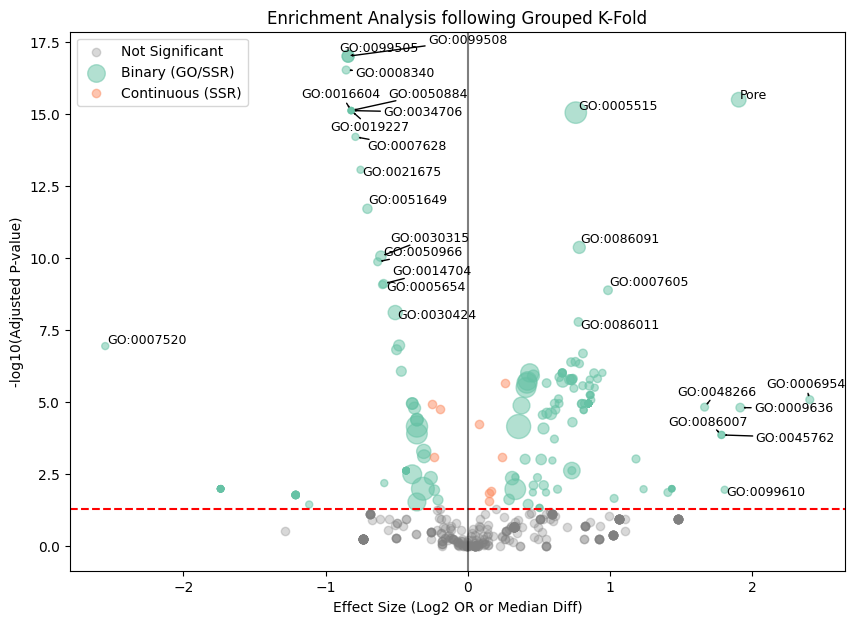

In [492]:
## Group Fold enrichment

# rep = enrichment.perform_model_audit_standarized(df)
# rep_invalid = rep.loc[rep['effect_size'] < -5]
# rep_valid = rep.loc[(rep['effect_size'] > -5) & (rep['effect_size'] < 5)]

enrichment.plot_audit_volcano(
    rep_valid.copy(), 
    effect_thresh=1.7, pos_thresh=1.6, neg_thresh=-2, 
    save='group_fold_enrichment', 
    title='Enrichment Analysis following Grouped K-Fold',
    var_df = df)

In [826]:

def count_genes(goid, df):
    return df.loc[df[goid] == 1]['gene'].unique()

print('-----------------')
print(count_genes('GO:0099508', df))
print('-----------------')
print(count_genes('GO:0099505', df))
print('-----------------')
print(count_genes('GO:0008340', df))

-----------------
['KCNA2' 'KCNA4' 'KCNC1' 'KCNC2' 'KCNJ11' 'KCNJ8' 'KCNQ5' 'SCN10A' 'SCN1A'
 'KCNJ3']
-----------------
['KCNA2' 'KCNA4' 'KCNC1' 'KCNC2' 'KCNJ11' 'KCNJ8' 'KCNQ5' 'SCN10A' 'SCN1A'
 'KCNJ3']
-----------------
['KCNJ11' 'KCNJ8' 'SCN1A']


In [174]:
# rep_valid_sorted = rep_valid.sort_values(by='neg_log10_p', ascending=False)

# def count_genes(goid):
#     return df.loc[df[goid] == 1]['gene'].unique()


# rep_valid_sorted['genes'] = rep_valid_sorted['feature'].apply(count_genes)
# print(rep_valid_sorted.head(10))

# rep_valid_sorted.to_csv('./group_fold_go_enrichment.csv', index=False)

In [87]:
def load_enrichment_results():
    runs = {'MissION': 'fixed_heyne_1'}
    runs = load_run_dict(runs)

    df = pd.read_csv("../Data/fixed_heyne.csv")
    out = []

    folds = runs['MissION']
    xs = []
    for f in folds:
        if int(f.fold) < 10:
            xs.append(f)
    folds = xs
    for fold in folds:
        best_epoch = fold.get_best_epoch()
        preds = fold.preds[best_epoch, :, :]
        y_pred = np.argmax(preds, 1)
        y_true = np.argmax(fold.labels[best_epoch, :, :], 1)
        varids = fold.varids[best_epoch]
    
        values = np.array(y_pred == y_true).astype(int)
        
        maps = list(zip(varids, values))
        out.extend(maps)
    
    out = pd.DataFrame(out, columns=['VarID', 'prediction_correct'])
    df = df.merge(out, on='VarID')
    return df

df = load_enrichment_results()

df = encode_go_terms(df)
to_drop = ['HPOTerms', "HPOTermParents", 'gene_B', 
           'original_aa', 'substituted_aa', 'sequence', 'GOTerms', 
           'position', 'MIM', 'Source', 'VarID', 'netChange']#, 'gene']
df = df.drop(columns = to_drop)


> load_run :: 0.996 sec


In [88]:
rep = enrichment.perform_model_audit_standarized(df)
rep_invalid = rep.loc[rep['effect_size'] < -5]
rep_valid = rep.loc[(rep['effect_size'] > -5) & (rep['effect_size'] < 5)]

12 [-0.00373766  0.28095982]
13 [ 0.21312495 -0.32495463]
14 [-0.87748592  0.08900832]
15 [-0.63456325 -0.70846347]
16 [-0.72194388  0.65735528]
18 [ 0.08844798 -0.35835273]
19 [-0.95103442 -0.25427904]
2 [-0.79550738  0.24010501]
3 [ 0.39538533 -0.75724084]
./review_figures/png/mission_skf_enrichment.png
./review_figures/pdf/mission_skf_enrichment.pdf


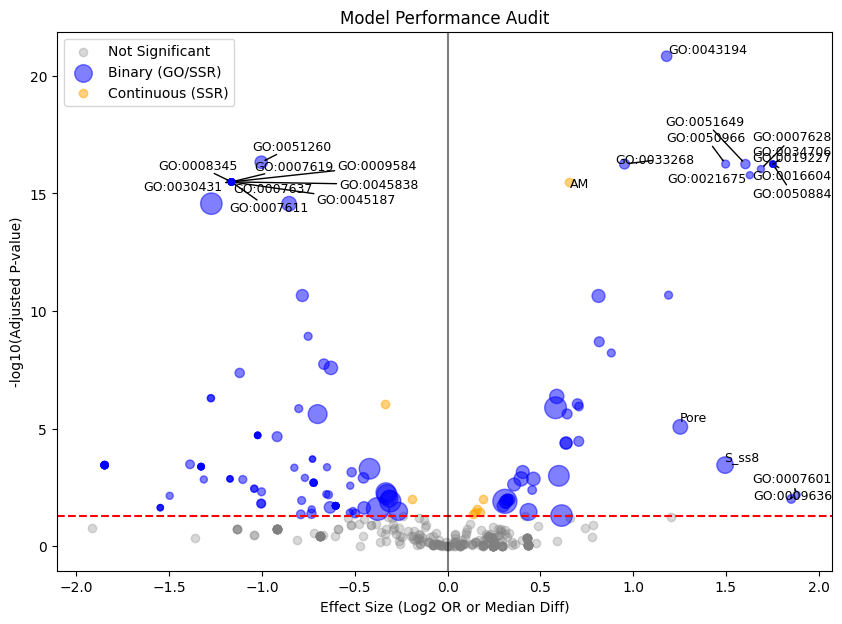

In [95]:
enrichment.plot_audit_volcano(
    rep_valid.copy(), 
    effect_thresh=1.7, pos_thresh=1.2, neg_thresh=-2, 
    save='mission_skf_enrichment', 
    title='Model performance following Stratified K-Fold',
    var_df = df)

---

# ESM PCA analysis

---

In [16]:
import safetensors 
from sklearn.decomposition import PCA
varids = df['VarID']
nc = df['netChange']
pc = df['prediction_correct']
varids
def load_st(varid: str):
    pos = int(varid.split('_')[2]) - 1
    gene = varid.split('_')[0]
    path = f"../Data/esm2_t36_3B_UR50D/{varid}.safetensors"
    emb = safetensors.safe_open(path, framework = 'pt')
    wt = safetensors.safe_open(f"../Data/esm2_t36_3B_UR50D/{gene}.safetensors", framework='pt')
    wt_emb = wt.get_tensor('emb')[0, pos]
    emb = emb.get_tensor('emb')[0, pos]
    # emb -= wt_emb
    return emb

In [17]:
embs = np.zeros((len(varids), 2560))
for i, varid in enumerate(varids):
    e = load_st(varid)
    embs[i] = np.array(e)

In [18]:

X = embs

pca = PCA(n_components=2)
pca.fit(X)
PCA(n_components=2)
print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[0.10462    0.04917973]
[122.31154999  83.85967428]


In [19]:
Y = pca.fit_transform(X)
print(Y.shape)

(1996, 2)


In [20]:
import umap
reducer = umap.UMAP()
Y = reducer.fit_transform(X)

/home/sean/.pyenv/versions/3.9.16/envs/esmpy/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/home/sean/.pyenv/versions/3.9.16/envs/esmpy/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sean/.pyenv/versions/3.9.16/envs/esmpy/lib/python3.9/site-packages/umap/plot.py:895: UserWarning: Hammer edge bundling is expensive for large graphs!
This may take a long time to compute!
  warn(


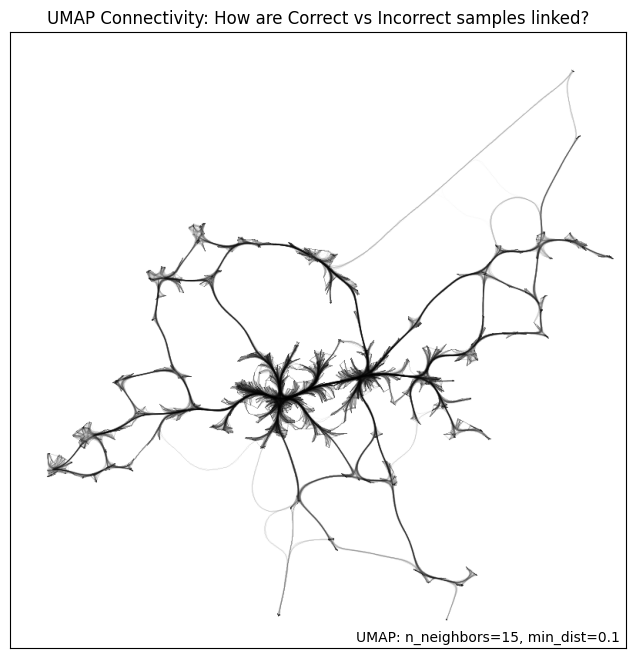

In [23]:
import umap.plot # Requires: pip install umap-learn[plot]
import matplotlib.pyplot as plt

labels = np.array([i == 0 for i in pc])
# 1. Fit the UMAP mapper (important: keep the 'mapper' object)
mapper = umap.UMAP(
    n_neighbors=15, 
    min_dist=0.1, 
    metric='cosine' # Cosine is often better for 2000+ dim embeddings
).fit(X)

# 2. Create the connectivity plot
# We color by 'correctness' (0 or 1)
umap.plot.connectivity(mapper, edge_bundling='hammer', labels=labels)
plt.title("UMAP Connectivity: How are Correct vs Incorrect samples linked?")
plt.show()

In [519]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

def analyze_embedding_enrichment(embeddings, labels):
    """
    embeddings: numpy array of shape (n_samples, 2560)
    labels: list/array of 0 (Incorrect) and 1 (Correct)
    """
    results = []
    
    for i in range(embeddings.shape[1]):
        dim_values = embeddings[:, i]
        correct = dim_values[labels == 1]
        incorrect = dim_values[labels == 0]
        
        # Mann-Whitney is safer than T-test for embeddings
        stat, p = mannwhitneyu(correct, incorrect)
        
        # Calculate effect size (Mean Difference)
        mean_diff = np.mean(correct) - np.mean(incorrect)
        
        results.append({'dim': i, 'p_value': p, 'diff': mean_diff})
        
    df = pd.DataFrame(results)
    _, df['p_adj'], _, _ = multipletests(df['p_value'], method='fdr_bh') # FDR is better for 2560 tests
    
    # Significant dimensions
    sig_dims = df[df['p_adj'] < 0.05].sort_values('p_adj')
    return sig_dims

# sig_dims = analyze_embedding_enrichment(X, label)
# sig_dims

p_adj = sig_dims[['dim', 'p_adj']]

xx = np.ones((2560,))
for i in range(2560):
    try:
        temp = p_adj.loc[p_adj['dim'] == i]['p_adj'].item()
    except ValueError as e:
        temp = 0.06
    xx[i] = temp

plt.figure(figsize=(12,4.8))
plt.scatter(range(2560), xx)

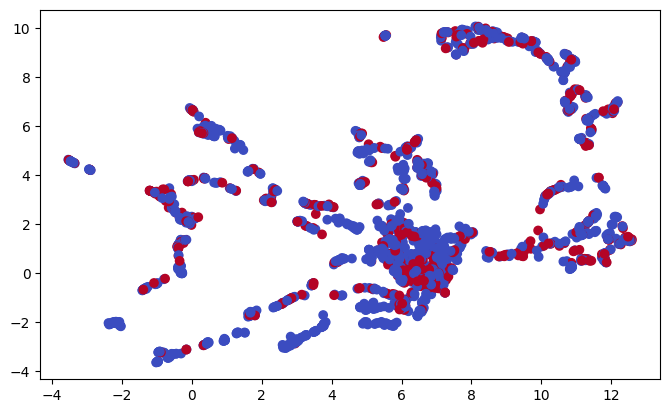

In [518]:
label = np.array([i == 'lof' for i in nc])
label = np.array([i == 0 for i in pc])
# df['gene'] = df['VarID'].apply(lambda x: x.split('_')[0])
# df['gene_id'] = df['gene'].astype('category').cat.codes
# label = df['gene_id']


plt.figure(figsize=(8, 4.8))
# plt.scatter(Y[label, 0], Y[label, 1], color='red')
# plt.scatter(Y[~label, 0], Y[~label, 1], color='blue')
plt.scatter(Y[:, 0], Y[:, 1], c=label, cmap='coolwarm')
plt.show()

---

# Cut size

---

In [187]:
runs = {
    '1': 'Fixed_Heyne/cut_size/1',
    '5': 'Fixed_Heyne/cut_size/5',
    '10': 'Fixed_Heyne/cut_size/10',
    '50': 'Fixed_Heyne/cut_size/50',
    '100': 'Fixed_Heyne/cut_size/100',
    '200': 'Fixed_Heyne/cut_size/200',
    '300': 'Fixed_Heyne/cut_size/300',
    '400': 'Fixed_Heyne/cut_size/400',
    '500': 'Fixed_Heyne/cut_size/500',
}
runs = load_run_dict(runs)

> load_run :: 0.540 sec
> load_run :: 0.495 sec
> load_run :: 0.512 sec
> load_run :: 0.447 sec
> load_run :: 0.500 sec
> load_run :: 0.448 sec
> load_run :: 0.536 sec
> load_run :: 0.490 sec
> load_run :: 0.467 sec


./review_figures/png/Supplementary_Cut_size.png


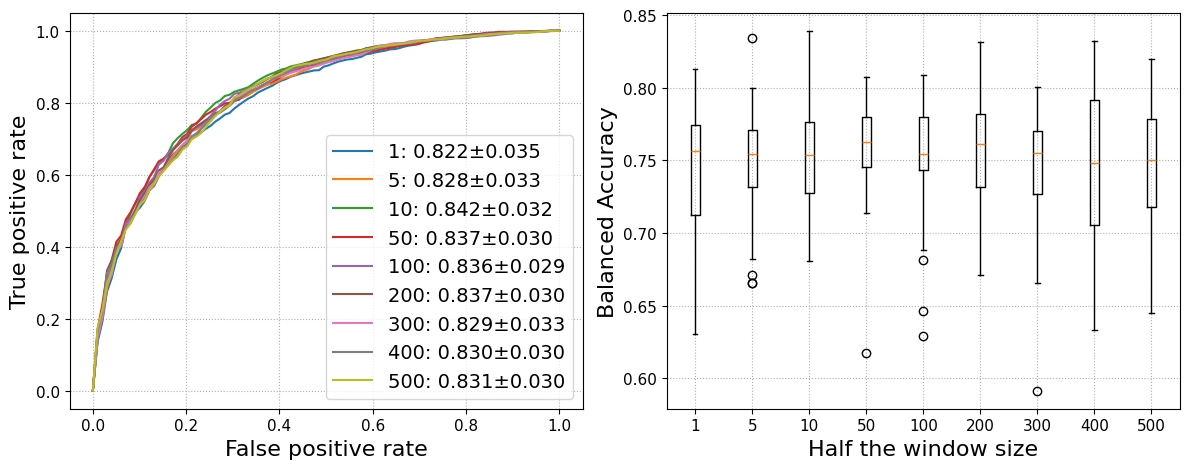

In [199]:
fig_size = (12, 4.8)

fig, ax = plt.subplots(1, 2, figsize=fig_size, tight_layout=True)

fontsize_title = 16
fontsize_suptitle = 18
fontsize_label = 16

for k, v in runs.items():
    roc_d = compute_roc(v)
    ax[0].plot(roc_d['fpr'], roc_d['tpr'], linewidth=1.5, label=f"{k}: {roc_d['auc']:.3f}±{roc_d['std']:.3f}")


ax[0].grid(linestyle=':')
ax[0].legend(fontsize=14)
# ax[0].set_title("ROC Curve", fontsize=fontsize_title)
ax[0].set_xlabel("False positive rate", fontsize=fontsize_label)
ax[0].set_ylabel("True positive rate", fontsize=fontsize_label)
# ----------------- ax-1 --------------------

# roc_d = compute_pr(runs['ours'])
# ax[1].plot(roc_d['recall'], roc_d['precision'],  linewidth=1.5, label=f"MissION: {roc_d['score']:.3f}")
# for k, v in runs.items():
#     roc_d = compute_pr(v)
#     ax[1].plot(roc_d['recall'], roc_d['precision'], linewidth=1.5, label=f"{k}: {roc_d['score']:.3f}")


def compute_ba(folds):
    scores = []
    for fold in folds:
        be = fold.best_epoch
        p = np.argmax(fold.preds[be, :], 1)
        l = np.argmax(fold.labels[be, :], 1)

        ba = balanced_accuracy_score(p, l)
        scores.append(ba)
    return scores

for idx, (k, v) in enumerate(runs.items()):
    ba_scores = compute_ba(v)
    
    ax[1].boxplot(ba_scores, positions=[idx])


ax[1].set_xticklabels(runs.keys())
ax[1].grid(linestyle=':')
# ax[1].legend(fontsize=14, loc=3)
# ax[1].set_title("PR curve", fontsize=fontsize_title)
ax[1].set_xlabel("Half the window size", fontsize=fontsize_label)
ax[1].set_ylabel("Balanced Accuracy", fontsize=fontsize_label)

for i in [0, 1]:
    ax[i].tick_params(axis='x', labelsize=11)
    ax[i].tick_params(axis='y', labelsize=11)

# plt.suptitle("Repeated Stratified K-Fold", fontsize=fontsize_suptitle)

save_fig(fig, 'Supplementary_Cut_size', fig_dir='./review_figures/', fig_fmt='png', fig_size=fig_size, transparent_png=False, dpi=300)
plt.show()


# Table 1

Compare our model to SCION & funNCion

In [67]:
runs = {
    'MissION': 'fixed_heyne_1',
    '(svm)SCION': 'fixed_heyne_svm',
    # '(gbm)funNCion': 'heyne_impute_scaler_output_rskf_2', # _2 => hyperparameter tuned

    '(gbm)funNCion': 'Out_v2/heyne_impute_scaler_output_rskf',

    # HPO
    # 'MissION': 'fixed_heyne_hpo_only',
    # '(svm)SCION': 'fixed_heyne_mkl',
}
runs = load_run_dict(runs)

> load_run :: 0.581 sec
> load_run :: 0.034 sec
> load_run :: 0.022 sec


In [68]:
def compute_metrics(folds, svm=False):
    scores = defaultdict(list)
    genes = []
    for fold_idx, fold in enumerate(folds):
        if not svm:
            genes.append(fold.varids[0][0].split('_')[0])
        else:
            genes.append(fold.varids[0].split('_')[0])
        be = fold.get_best_epoch()
        preds = fold.preds[be]
        labels = fold.labels[be]
        
        
        if preds.ndim > 1:
            gof_proba = preds[:, 1]
            pred_label = np.argmax(preds, 1)
            true_label = np.argmax(labels, 1)
        else:
            true_label = labels
            gof_proba = preds
            pred_label = (gof_proba > 0).astype(int)


        # ROC AUC
        scores['ROC-AUC'].append(
            roc_auc_score(true_label, gof_proba)
        )

        # precision, recall, _ = precision_recall_curve(true_label, gof_proba)
        # scores['PR-AUC'].append(auc(recall, precision))

        # Precision
        scores['Precision'].append(
            precision_score(true_label, pred_label)
        )
        #Recall
        scores['Recall'].append(
            recall_score(true_label, pred_label)
        )
        scores['PR-AUC'].append(
            average_precision_score(true_label, gof_proba)
        )
        # MCC
        scores['MCC'].append(
            matthews_corrcoef(true_label, pred_label)
        )
        f1_averages = ['weighted', 'macro', 'binary']
        for avg in f1_averages:
            scores[f'F1-{avg}'].append(
                f1_score(true_label, pred_label, labels=[0, 1], average=avg)
            )
        # Accuracy
        scores['Accuracy'].append(
            accuracy_score(true_label, pred_label)
        )
        # Balanced Accuracy
        scores['BA'].append(
            balanced_accuracy_score(true_label, pred_label)
        )
    return scores

In [69]:
scores_dict = {}
for idx, (k,v) in enumerate(runs.items()):
    scores = compute_metrics(v, '(svm)' in k or '(gbm)' in k)
    scores_dict[k] = scores
    print(f'----- {k} -----')
    for k, v in scores.items():
        # print(k, np.mean(v), np.std(v))
        print(f"{k}: {np.mean(v):.3f} {np.std(v):.3f}")


----- MissION -----
ROC-AUC: 0.918 0.017
Precision: 0.786 0.053
Recall: 0.671 0.059
PR-AUC: 0.842 0.032
MCC: 0.627 0.052
F1-weighted: 0.848 0.021
F1-macro: 0.810 0.027
F1-binary: 0.722 0.041
Accuracy: 0.852 0.020
BA: 0.798 0.029
----- (svm)SCION -----
ROC-AUC: 0.884 0.019
Precision: 0.662 0.046
Recall: 0.785 0.038
PR-AUC: 0.789 0.050
MCC: 0.595 0.046
F1-weighted: 0.826 0.023
F1-macro: 0.793 0.025
F1-binary: 0.717 0.031
Accuracy: 0.822 0.025
BA: 0.811 0.022
----- (gbm)funNCion -----
ROC-AUC: 0.779 0.033
Precision: 0.612 0.066
Recall: 0.422 0.062
PR-AUC: 0.594 0.056
MCC: 0.356 0.070
F1-weighted: 0.741 0.027
F1-macro: 0.668 0.036
F1-binary: 0.497 0.057
Accuracy: 0.757 0.026
BA: 0.657 0.033


In [78]:
# metric = 'PR-AUC'
metric = 'MCC'
# metric = 'F1-binary'
x = {}
x['MissION'] = scores_dict['MissION'][metric]
x['SCION'] = scores_dict['(svm)SCION'][metric]
x['funNCion'] = scores_dict['(gbm)funNCion'][metric]

results = []
for m1, m2 in combinations(x.keys(), 2):
    stat, p_value = wilcoxon(x[m1], x[m2])
    results.append({
        "comparison": f"{m1} vs {m2}",
        "statistic": stat,
        "p_value": p_value
    })

# # 1. Correct Alpha
# alpha = 0.05 

# # 2. n_tests should be the number of comparisons (3 models = 3 comparisons)
# comparisons = list(combinations(x.keys(), 2))
# n_tests = len(comparisons)

# results = []
# for m1, m2 in comparisons:
#     stat, p_value = wilcoxon(x[m1], x[m2])
    
#     # Bonferroni adjustment
#     p_corr = min(p_value * n_tests, 1.0)
    
#     results.append({
#         "comparison": f"{m1} vs {m2}",
#         "p_val": p_value,
#         "p_val_adj": p_corr,
#         "significant": p_corr < alpha
#     })
# pprint.pprint(results)

[{'comparison': 'MissION vs SCION',
  'p_val': 0.0003449581563472748,
  'p_val_adj': 0.0010348744690418243,
  'significant': True},
 {'comparison': 'MissION vs funNCion',
  'p_val': 1.862645149230957e-09,
  'p_val_adj': 5.587935447692871e-09,
  'significant': True},
 {'comparison': 'SCION vs funNCion',
  'p_val': 1.862645149230957e-09,
  'p_val_adj': 5.587935447692871e-09,
  'significant': True}]


In [79]:
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

data = np.array([x['MissION'], x['SCION'], x['funNCion']]).T
df = pd.DataFrame(data, columns=['MissION', 'SCION', 'funNCion'])


# 2. Friedman Test
# stat, p = friedmanchisquare(*data.T)
stat, p = friedmanchisquare(df['MissION'], df['SCION'], df['funNCion'])
print(f"Friedman={stat:.4f} P-value: {p:.4f}")

if p < 0.05:
    # 3. Nemenyi Post-hoc Test
    # This returns a heatmap/table of p-values for all pairs
    p_values = sp.posthoc_nemenyi_friedman(df)
    print("\nPairwise P-values (Nemenyi):")
    print(p_values)
else:
    print("No significant difference found across models.")

Friedman=47.4000 P-value: 0.0000

Pairwise P-values (Nemenyi):
               MissION     SCION      funNCion
MissION   1.000000e+00  0.268023  1.373062e-10
SCION     2.680233e-01  1.000000  1.430586e-06
funNCion  1.373062e-10  0.000001  1.000000e+00


In [80]:
def corrected_resampled_t_test(scores1, scores2, n_repeats, n_folds):
    """
    Computes the Nadeau and Bengio Corrected Resampled t-test.
    """
    # 1. Calculate differences
    differences = np.array(scores1) - np.array(scores2)
    n = len(differences)  # Total number of observations (repeats * folds)
    
    # 2. Basic statistics
    mean_diff = np.mean(differences)
    var_diff = np.var(differences, ddof=1)
    
    # 3. Correction factor (rho)
    # rho = ratio of test samples to training samples
    # For 10-fold CV, test=1/10, train=9/10 -> rho = 1/9
    rho = 1 / n_folds 
    
    # 4. Corrected t-statistic
    # Variance is scaled by (1/n + rho)
    corrected_var = (1/n + rho) * var_diff
    t_stat = mean_diff / np.sqrt(corrected_var)
    
    # 5. P-value (Two-tailed)
    # Degrees of freedom is n - 1
    p_val = stats.t.sf(np.abs(t_stat), n-1) * 2
    
    return t_stat, p_val

t_stat, p_val = corrected_resampled_t_test(df['MissION'].to_numpy(), df['SCION'].to_numpy(), n_repeats = 3, n_folds=10)
print('MissION v. SCION:', t_stat, p_val)

t_stat, p_val = corrected_resampled_t_test(df['MissION'].to_numpy(), df['funNCion'].to_numpy(), n_repeats = 3, n_folds=10)
print('MissION v. funNCion:', t_stat, p_val)

t_stat, p_val = corrected_resampled_t_test(df['SCION'].to_numpy(), df['funNCion'].to_numpy(), n_repeats = 3, n_folds=10)
print('SCION v. funNCion:', t_stat, p_val)

MissION v. SCION: 2.149445891632178 0.04007566552780873
MissION v. funNCion: 7.7733767569572985 1.4262988573186197e-08
SCION v. funNCion: 7.228558463256399 5.855457753901154e-08


In [81]:
metrics = scores_dict['MissION'].keys()
for metric in metrics:
    
    x = {}
    x['MissION'] = scores_dict['MissION'][metric]
    x['SCION'] = scores_dict['(svm)SCION'][metric]
    # x['funNCion'] = scores_dict['(gbm)funNCion'][metric]
    data = np.array([x['MissION'], x['SCION']]).T#, x['funNCion']]).T
    df = pd.DataFrame(data, columns=['MissION', 'SCION'])#, 'funNCion'])

    t_stat, p_val = corrected_resampled_t_test(df['MissION'].to_numpy(), df['SCION'].to_numpy(), n_repeats = 3, n_folds=10)
    print(f'{metric:12} MissION v. SCION:', t_stat, p_val)
    
    # t_stat, p_val = corrected_resampled_t_test(df['MissION'].to_numpy(), df['funNCion'].to_numpy(), n_repeats = 3, n_folds=10)
    # print('MissION v. funNCion:', t_stat, p_val)
    
    # t_stat, p_val = corrected_resampled_t_test(df['SCION'].to_numpy(), df['funNCion'].to_numpy(), n_repeats = 3, n_folds=10)
    # print('SCION v. funNCion:', t_stat, p_val)

ROC-AUC      MissION v. SCION: 5.491922757234511 6.4701387558258006e-06
Precision    MissION v. SCION: 6.225482654527339 8.59647725045527e-07
Recall       MissION v. SCION: -6.007161433252865 1.5618047109358648e-06
PR-AUC       MissION v. SCION: 3.7406130326959004 0.0008051772892497983
MCC          MissION v. SCION: 2.149445891632178 0.04007566552780873
F1-weighted  MissION v. SCION: 2.938542669656588 0.006406716550814151
F1-macro     MissION v. SCION: 1.9330089588902652 0.06305249686408207
F1-binary    MissION v. SCION: 0.3656155373785603 0.7173054063097406
Accuracy     MissION v. SCION: 3.8418184934935637 0.0006136363486650298
BA           MissION v. SCION: -1.5809486300995053 0.12473649825934761
